# ЗАГРУЗКА ДАТАСЕТА

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [7]:
# Download latest version
path = kagglehub.dataset_download("olistbr/marketing-funnel-olist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'marketing-funnel-olist' dataset.
Path to dataset files: /kaggle/input/marketing-funnel-olist


In [8]:
base = "/kaggle/input/brazilian-ecommerce"
funnel_base = "/kaggle/input/marketing-funnel-olist"

#base
customers = pd.read_csv(f"{base}/olist_customers_dataset.csv")
orders = pd.read_csv(f"{base}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{base}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{base}/olist_products_dataset.csv")
payments = pd.read_csv(f"{base}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{base}/olist_order_reviews_dataset.csv")
sellers = pd.read_csv(f"{base}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{base}/olist_geolocation_dataset.csv")
cat_transl = pd.read_csv(f"{base}/product_category_name_translation.csv")

#funnel_base
closed_deals = pd.read_csv(f"{funnel_base}/olist_closed_deals_dataset.csv")
mql_leads = pd.read_csv(f"{funnel_base}/olist_marketing_qualified_leads_dataset.csv")


#EDA-АНАЛИЗ

##CUSTOMERS (Клиенты)


Форма: (99441, 5)

Первые 5 строк:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Пропуски:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Уникальных значений:
customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64


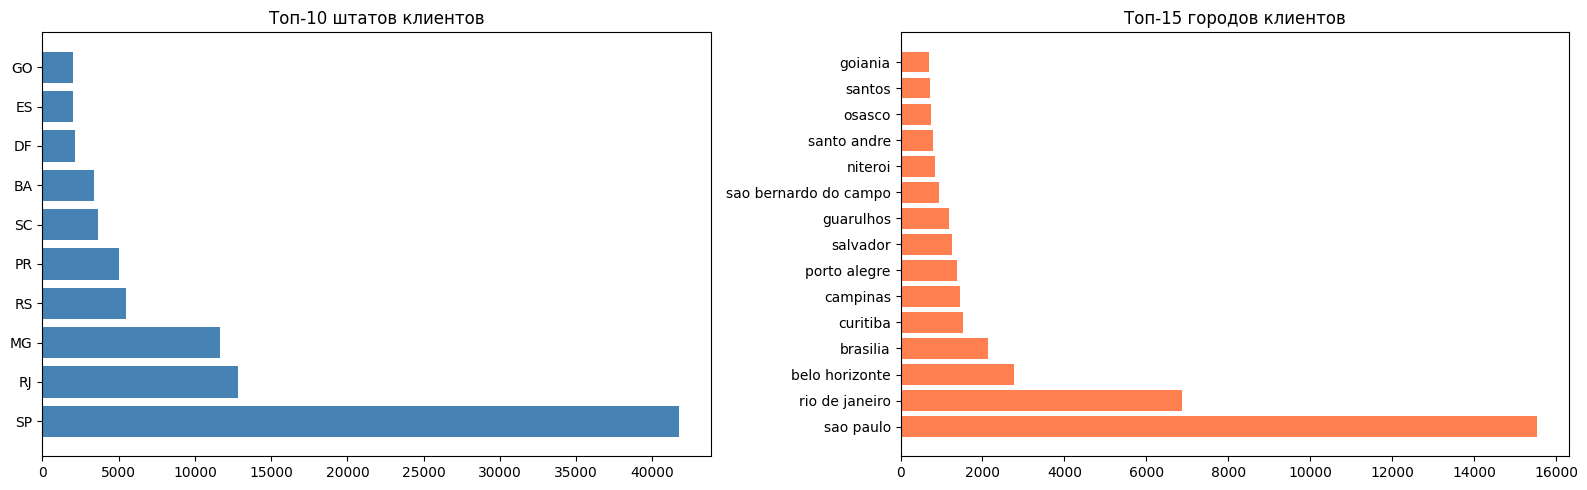

In [9]:
print(f"Форма: {customers.shape}")
print("\nПервые 5 строк:")
display(customers.head())
print("\nПропуски:")
print(customers.isnull().sum())
print("\nУникальных значений:")
print(customers.nunique())

fig, axes = plt.subplots(1,2, figsize=(16,5))
top_states = customers['customer_state'].value_counts().nlargest(10)
axes[0].barh(top_states.index, top_states.values, color='steelblue')
axes[0].set_title('Топ‑10 штатов клиентов')
top_cities = customers['customer_city'].value_counts().nlargest(15)
axes[1].barh(top_cities.index, top_cities.values, color='coral')
axes[1].set_title('Топ‑15 городов клиентов')
plt.tight_layout()
plt.show()


##ORDERS (Заказы)

Форма: (99441, 8)

Пропуски:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Статусы заказов:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


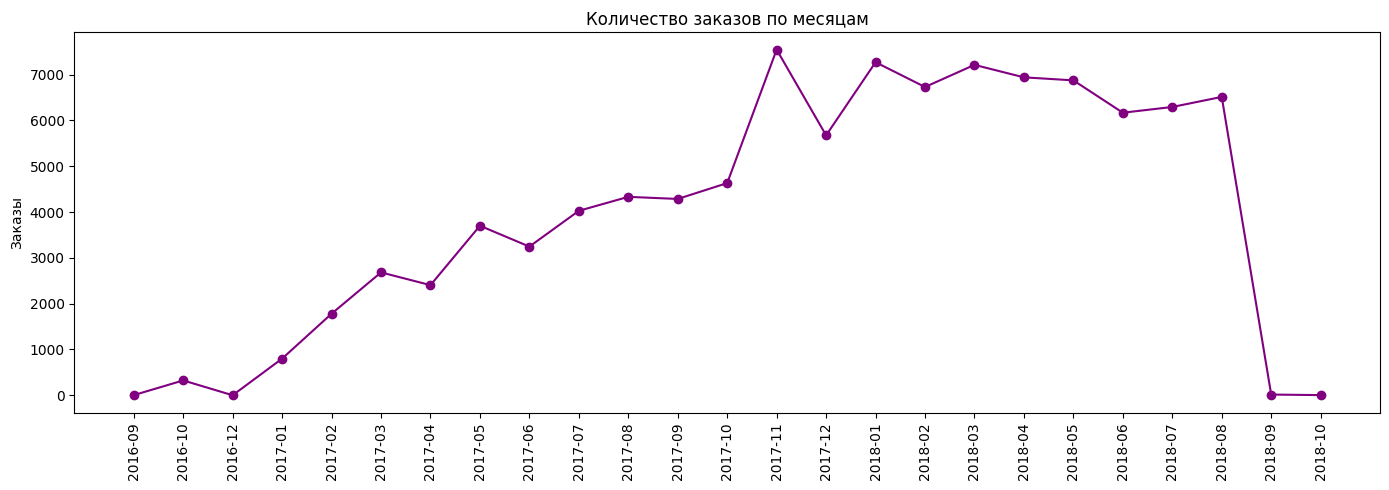

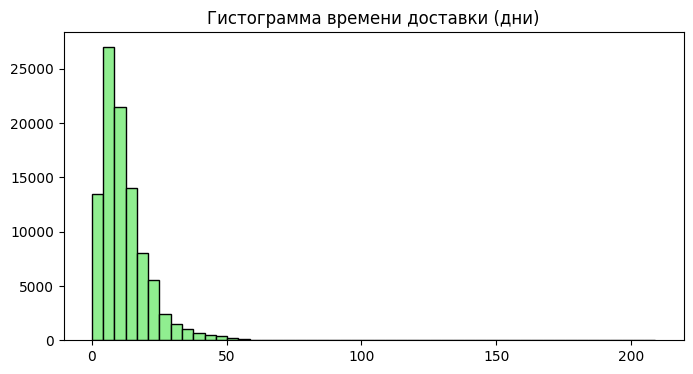

In [10]:
print(f"Форма: {orders.shape}")
print("\nПропуски:")
print(orders.isnull().sum())
print("\nСтатусы заказов:")
print(orders['order_status'].value_counts())

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# График по месяцам
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
month_counts = orders['month'].value_counts().sort_index()
plt.figure(figsize=(14,5))
plt.plot(month_counts.index, month_counts.values, color='purple', marker='o')
plt.xticks(rotation=90)
plt.title('Количество заказов по месяцам')
plt.ylabel('Заказы')
plt.tight_layout()
plt.show()

# Распределение времени доставки (в днях) для доставленных
delivered = orders[orders['order_status']=='delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
plt.figure(figsize=(8,4))
plt.hist(delivered['delivery_days'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Гистограмма времени доставки (дни)')
plt.show()

In [11]:
orders_del = orders[orders['order_status'] == 'delivered'].copy()

print("\nПропуски в доставленных заказах:")
print(orders_del.isnull().sum())


Пропуски в доставленных заказах:
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
month                             0
dtype: int64


##ORDER_ITEMS + PAYMENTS + REVIEWS (Товары в заказах, платежи, отзывы)

ORDER_ITEMS
Форма: (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Пропуски:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Цена товара (price):
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

Стоимость доставки (freight_value):
count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64


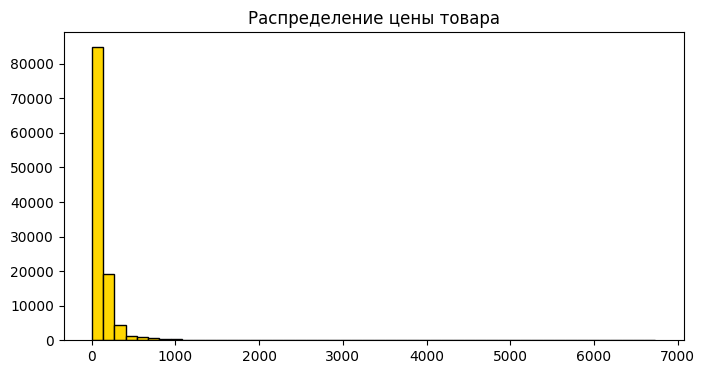

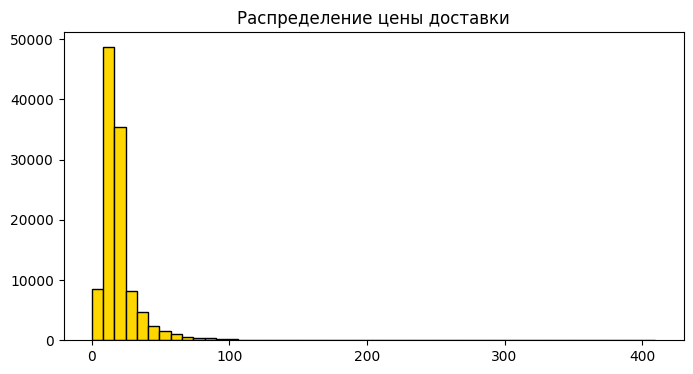

In [12]:
print("ORDER_ITEMS")
print(f"Форма: {order_items.shape}")
display(order_items.head())
print("\nПропуски:")
print(order_items.isnull().sum())
print("\nЦена товара (price):")
print(order_items['price'].describe())
print("\nСтоимость доставки (freight_value):")
print(order_items['freight_value'].describe())

plt.figure(figsize=(8,4))
plt.hist(order_items['price'], bins=50, color='gold', edgecolor='black')
plt.title('Распределение цены товара')
plt.show()

plt.figure(figsize=(8,4))
plt.hist(order_items['freight_value'], bins=50, color='gold', edgecolor='black')
plt.title('Распределение цены доставки')
plt.show()

In [13]:
# PAYMENTS
print("PAYMENTS")
print(f"Форма: {payments.shape}")
display(payments.head())
print("\nПропуски:")
print(payments.isnull().sum())
print("\nТипы оплат:")
print(payments['payment_type'].value_counts())
print("\nСумма платежа (payment_value):")
print(payments['payment_value'].describe())

PAYMENTS
Форма: (103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



Пропуски:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Типы оплат:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Сумма платежа (payment_value):
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64


REVIEWS
Форма: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



Пропуски:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Оценки (review_score):
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


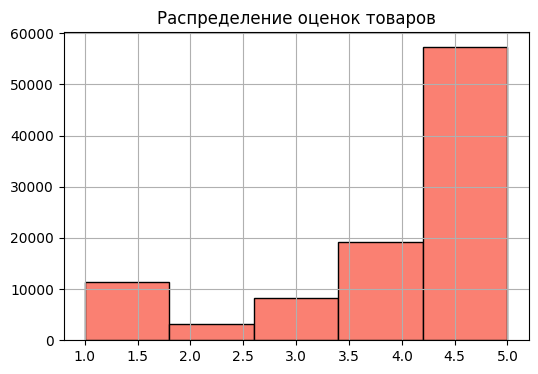

In [14]:
# REVIEWS
print("REVIEWS")
print(f"Форма: {reviews.shape}")
display(reviews.head())
print("\nПропуски:")
print(reviews.isnull().sum())
print("\nОценки (review_score):")
print(reviews['review_score'].value_counts().sort_index())

plt.figure(figsize=(6,4))
reviews['review_score'].hist(bins=5, color='salmon', edgecolor='black')
plt.title('Распределение оценок товаров')
plt.show()

 ## PRODUCTS (Товары)

ТАБЛИЦА: PRODUCTS
Форма: (32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



Пропуски:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Описание числовых колонок:
       product_name_lenght  product_description_lenght  product_photos_qty  \
count         32341.000000                32341.000000        32341.000000   
mean             48.476949                  771.495285            2.188986   
std              10.245741                  635.115225            1.736766   
min               5.000000                    4.000000            1.000000   
25%              42.000000                  339.000000            1.000000   
50%              51.000000                  595.000000            1.000000   
75%              57.000000                  972.000000            3.000000   
max              7

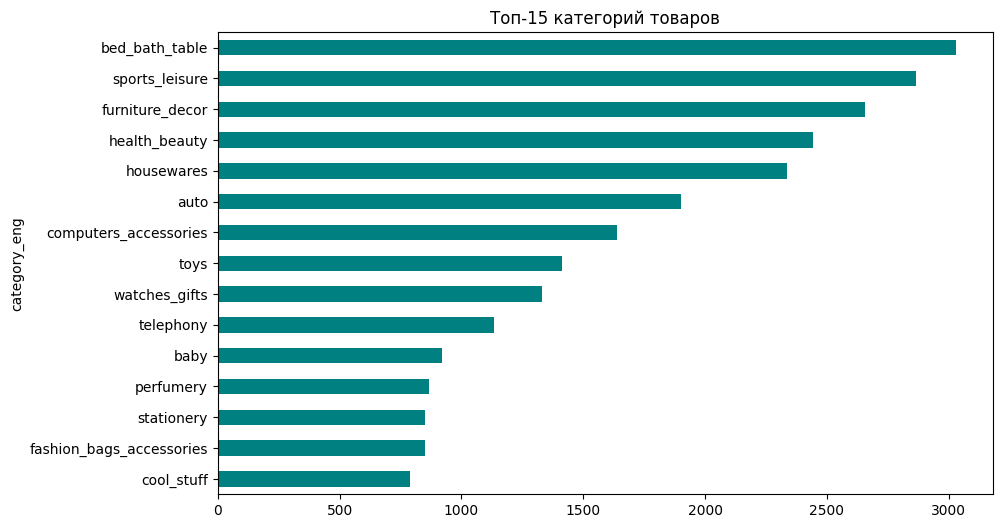

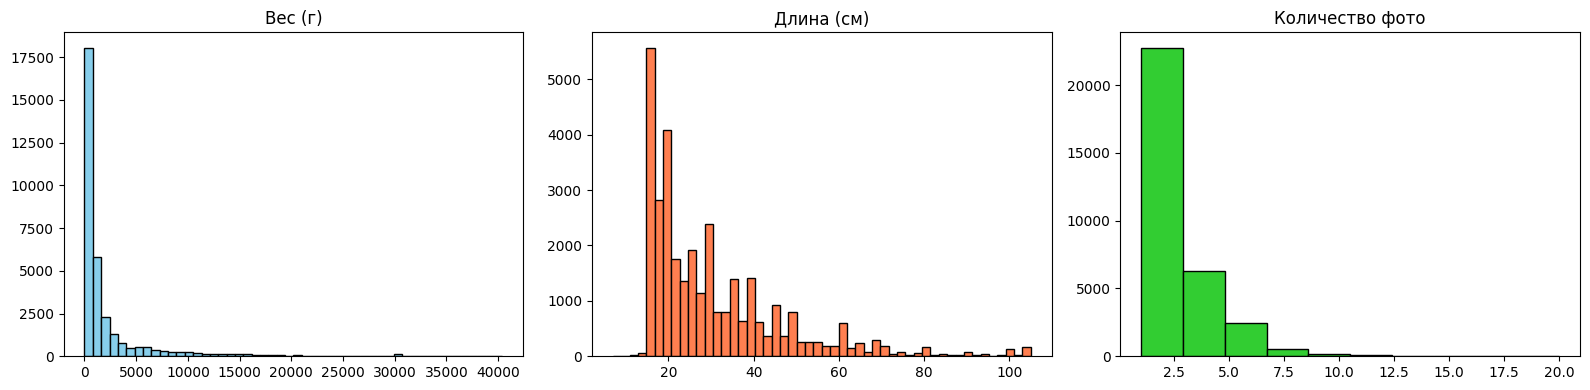

In [15]:
print("ТАБЛИЦА: PRODUCTS")
print(f"Форма: {products.shape}")
display(products.head())
print("\nПропуски:")
print(products.isnull().sum())
print("\nОписание числовых колонок:")
print(products.describe())

products_with_cat = products.merge(cat_transl, on='product_category_name', how='left')
products_with_cat['category_eng'] = products_with_cat['product_category_name_english'].fillna('other')
top_cats = products_with_cat['category_eng'].value_counts().nlargest(15)

plt.figure(figsize=(10,6))
top_cats.plot(kind='barh', color='teal')
plt.title('Топ‑15 категорий товаров')
plt.gca().invert_yaxis()
plt.show()

# Вес, размеры
fig, axes = plt.subplots(1,3, figsize=(16,4))
axes[0].hist(products['product_weight_g'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Вес (г)')
axes[1].hist(products['product_length_cm'].dropna(), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Длина (см)')
axes[2].hist(products['product_photos_qty'].dropna(), bins=10, color='limegreen', edgecolor='black')
axes[2].set_title('Количество фото')
plt.tight_layout()
plt.show()

In [16]:
missing_cat = products[products['product_category_name'].isnull() & products['product_name_lenght'].isnull() & products['product_description_lenght'].isnull() & products['product_photos_qty'].isnull()]
print(f"Товаров с пропущенными значениями: {missing_cat.shape[0]}")
print("Первые 5 таких товаров:")
display(missing_cat.head())

# Товары, у которых отсутствуют вес/размеры (но категория заполнена)
missing_weight = products[products['product_weight_g'].isnull() & products['product_length_cm'].isnull() & products['product_height_cm'].isnull() & products['product_width_cm'].isnull() & products['product_category_name'].notnull()]
print(f"\nТоваров с пропущенными остальными (но с категорией): {missing_weight.shape[0]}")
display(missing_weight.head())

Товаров с пропущенными значениями: 610
Первые 5 таких товаров:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0



Товаров с пропущенными остальными (но с категорией): 1


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN


## SELLERS (Продавцы) и GEOLOCATION

ТАБЛИЦА: SELLERS
Форма: (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Пропуски:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Топ‑10 штатов продавцов:
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64


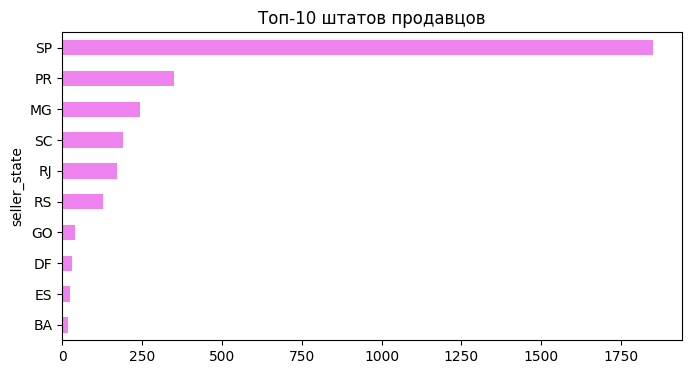

In [17]:
print("ТАБЛИЦА: SELLERS")
print(f"Форма: {sellers.shape}")
display(sellers.head())
print("\nПропуски:")
print(sellers.isnull().sum())
print("\nТоп‑10 штатов продавцов:")
print(sellers['seller_state'].value_counts().nlargest(10))

plt.figure(figsize=(8,4))
sellers['seller_state'].value_counts().nlargest(10).plot(kind='barh', color='violet')
plt.title('Топ‑10 штатов продавцов')
plt.gca().invert_yaxis()
plt.show()

In [18]:
#GEOLOCATION
print("ТАБЛИЦА: GEOLOCATION")
print(f"Форма: {geolocation.shape}")
display(geolocation.head())
print("\nПропуски:")
print(geolocation.isnull().sum())
print("\nУникальных zip‑префиксов:", geolocation['geolocation_zip_code_prefix'].nunique())

ТАБЛИЦА: GEOLOCATION
Форма: (1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



Пропуски:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Уникальных zip‑префиксов: 19015


## MARKETING FUNNEL

ТАБЛИЦА: CLOSED_DEALS (Успешные сделки с продавцами)
Форма: (842, 14)


,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,NaN,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,NaN,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,NaN,NaN,NaN,NaN,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,NaN,manufacturer,NaN,0.0



Пропуски:
mql_id                             0
seller_id                          0
sdr_id                             0
sr_id                              0
won_date                           0
business_segment                   1
lead_type                          6
lead_behaviour_profile           177
has_company                      779
has_gtin                         778
average_stock                    776
business_type                     10
declared_product_catalog_size    773
declared_monthly_revenue           0
dtype: int64

Бизнес‑сегменты (business_segment):
business_segment
home_decor                         105
health_beauty                       93
car_accessories                     77
household_utilities                 71
construction_tools_house_garden     69
audio_video_electronics             64
computers                           34
pet                                 30
food_supplement                     28
food_drink                          26
sports_leisure

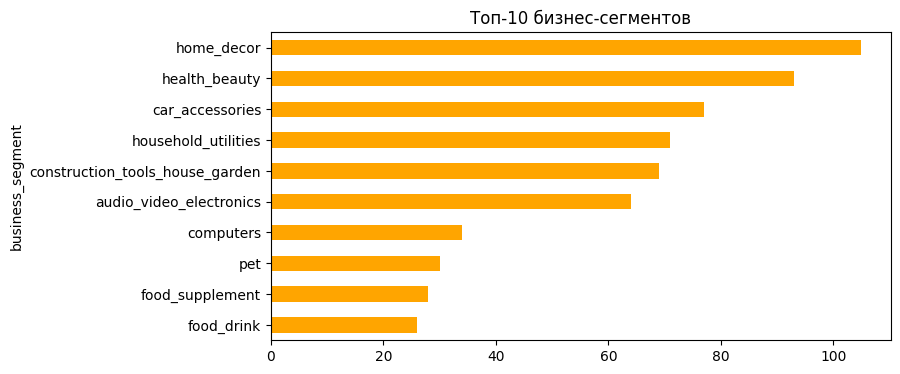

In [19]:
print("ТАБЛИЦА: CLOSED_DEALS (Успешные сделки с продавцами)")
print(f"Форма: {closed_deals.shape}")
display(closed_deals.head())
print("\nПропуски:")
print(closed_deals.isnull().sum())
print("\nБизнес‑сегменты (business_segment):")
print(closed_deals['business_segment'].value_counts())
print("\nТипы лидов (lead_type):")
print(closed_deals['lead_type'].value_counts())
print("\nОбъявленный месячный доход (declared_monthly_revenue):")
print(closed_deals['declared_monthly_revenue'].describe())

plt.figure(figsize=(8,4))
closed_deals['business_segment'].value_counts().nlargest(10).plot(kind='barh', color='orange')
plt.title('Топ‑10 бизнес‑сегментов')
plt.gca().invert_yaxis()
plt.show()



In [20]:
print("ТАБЛИЦА: MQL_LEADS (Маркетинговые лиды)")
print(f"Форма: {mql_leads.shape}")
display(mql_leads.head())
print("\nПропуски:")
print(mql_leads.isnull().sum())
print("\nИсточник (origin):")
print(mql_leads['origin'].value_counts())

ТАБЛИЦА: MQL_LEADS (Маркетинговые лиды)
Форма: (8000, 4)


,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search



Пропуски:
mql_id                 0
first_contact_date     0
landing_page_id        0
origin                60
dtype: int64

Источник (origin):
origin
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
Name: count, dtype: int64


## Вывод EDA - АНАЛИЗА.

**CUSTOMER (клиенты):**

1. Уникальных записей (customer_id) 99441, однако уникальных клиентов только (customer_unique_id) 96096. При необходимости использовать данное поле нужно ориентироваться именно на customer_unique_id.
2. Пропусков нет.
3. Городов слишком много для анализа, использовать customer_state (27 уникальных значений, которые можно сгруппировать).



**ORDERS (Заказы):**


1.   99441 уникальных записей.
2.   Есть пропуски.
3. Для кластеризации лучше использовать доставленные товары(delivered - 96478 записей), которых подовляющее большинство и почти отсутствуют пропуски. Также именно успешные и доставленные сделки мы хотим изучать.


**ORDER_ITEMS + PAYMENTS + REVIEWS (Товары в заказах, платежи, отзывы):**


1.   Использовать цену товара и ценудоставки.
2.   payment_type - важный показатель. Можно сгрупировать для выделение тех, кто любит оплачивать поле получения товара. Оплата сразу: credit_card, debit_card, voucher (сертификаты). Постоплата: boleto
3. В отзывах значительное количество пропусков, использовать нельзя.Оценку товара - необходимо.

**PRODUCTS (Товары):**

1. 32951 запись - наша цель для сегментации.
2. 610 пустых значений по видам и категории товаров. Необходимо ими пожертвовать для корректной работы модели.
3. Категории товаров нужно будет объединять в большие подгруппы.
4. Использовать английское название категорий товаров.

**SELLERS (Продавцы) и GEOLOCATION**



1. Есть регионы продавца
2. Остальные колонки в модели рассматривать не будем

**Marketing Funnel:**


1. 842 успешно привлечённых продавца
2. Бизнес‑сегменты: 33 уникальных значения – можно сгруппировать
3. Типы лидов (lead_type): 8 уникальных


**Далее формируем итоговый датасет,анализируем его для построения модели.**

# ФОРМИРОВАНИЕ ЕДИНОЙ ТАБЛИЦЫ ТОВАРОВ

Исходя из проведенного анализа свормируем первичную структуру таблицы:

1. Базовые характеристики товара (PRODUCTS):
* product_id - ключ
* category_group - группируем
* product_name_lenght, product_description_lenght,   product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm - характеристики товаров
* Записи с Null удаляем из списка как ошибки

2.   Статистики продаж:
* total_sold — сколько раз купили товар
* total_revenue — суммарная выручка
* avg_unit_price - средняя цена товара
* unique_customers — сколько уникальных покупателей
* n_sellers — количество разных продавцов, предлагавших этот товар

3. Качество товара
* avg_review_score — средняя оценка отзывов
* avg_delivery_days — среднее время доставки (в днях)
* sales_per_month — среднее количество продаж в месяц с момента первого появления товара

4. Географические признаки (на основе продавцов и покупателей)
* seller_region_top1 — топ регионов продавцов
* customer_region_top1 — топ‑ регионов покупателей

## Создание датасета

In [21]:
category_group_map = {
    # 1. Electronics (компактная техника, гаджеты)
    'audio': 'Electronics', 'cine_photo': 'Electronics', 'computers': 'Electronics',
    'computers_accessories': 'Electronics', 'consoles_games': 'Electronics',
    'dvds_blu_ray': 'Electronics', 'electronics': 'Electronics', 'fixed_telephony': 'Electronics',
    'tablets_printing_image': 'Electronics', 'telephony': 'Electronics',
    'small_appliances': 'Electronics', 'small_appliances_home_oven_and_coffee': 'Electronics',
    'musical_instruments': 'Electronics', 'air_conditioning': 'Electronics',

    # 2. Home & Decor (мебель, декор, посуда)
    'bed_bath_table': 'Home & Decor', 'furniture_bedroom': 'Home & Decor',
    'furniture_decor': 'Home & Decor', 'furniture_living_room': 'Home & Decor',
    'furniture_mattress_and_upholstery': 'Home & Decor', 'home_comfort_2': 'Home & Decor',
    'home_confort': 'Home & Decor', 'housewares': 'Home & Decor',
    'office_furniture': 'Home & Decor', 'kitchen_dining_laundry_garden_furniture': 'Home & Decor',
    'la_cuisine': 'Home & Decor',

    # 3. Construction & Tools (инструменты, стройка)
    'construction_tools_construction': 'Construction & Tools',
    'construction_tools_lights': 'Construction & Tools',
    'construction_tools_safety': 'Construction & Tools',
    'costruction_tools_garden': 'Construction & Tools',
    'costruction_tools_tools': 'Construction & Tools',
    'home_construction': 'Construction & Tools',
    'garden_tools': 'Construction & Tools',

    # 4. Fashion (одежда, обувь)
    'fashio_female_clothing': 'Fashion', 'fashion_male_clothing': 'Fashion',
    'fashion_childrens_clothes': 'Fashion', 'fashion_shoes': 'Fashion',
    'fashion_sport': 'Fashion', 'fashion_underwear_beach': 'Fashion',

    # 5. Accessories & Luggage (аксессуары, сумки, украшения)
    'fashion_bags_accessories': 'Accessories & Luggage',
    'luggage_accessories': 'Accessories & Luggage',
    'watches_gifts': 'Accessories & Luggage',

    # 6. Beauty & Health (красота, гигиена)
    'health_beauty': 'Beauty & Health', 'perfumery': 'Beauty & Health',
    'diapers_and_hygiene': 'Beauty & Health',

    # 7. Sports & Leisure (спорт, игры, хобби)
    'sports_leisure': 'Sports & Leisure', 'toys': 'Sports & Leisure',
    'art': 'Sports & Leisure', 'arts_and_craftmanship': 'Sports & Leisure',
    'music': 'Sports & Leisure', 'cds_dvds_musicals': 'Sports & Leisure',
    'cool_stuff': 'Sports & Leisure',

    # 8. Books & Stationery (книги, канцелярия)
    'books_general_interest': 'Books & Stationery', 'books_imported': 'Books & Stationery',
    'books_technical': 'Books & Stationery', 'stationery': 'Books & Stationery',

    # 9. Food & Drinks (продукты, напитки)
    'drinks': 'Food & Drinks', 'food': 'Food & Drinks', 'food_drink': 'Food & Drinks',

    # 10. Garden, B2B & Others (сад, промышленность, прочее)
    'agro_industry_and_commerce': 'Garden, B2B & Others',
    'flowers': 'Garden, B2B & Others',
    'industry_commerce_and_business': 'Garden, B2B & Others',
    'market_place': 'Garden, B2B & Others',
    'pet_shop': 'Garden, B2B & Others',
    'security_and_services': 'Garden, B2B & Others',
    'signaling_and_security': 'Garden, B2B & Others',
    'baby': 'Garden, B2B & Others',
    'christmas_supplies': 'Garden, B2B & Others',
    'party_supplies': 'Garden, B2B & Others',
}

region_map = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste',
    'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

In [22]:
# Удаляем товары без категории (610 шт.)
products_clean = products.dropna(subset=['product_category_name']).copy()
# Присоединяем английские названия
products_clean = products_clean.merge(cat_transl, on='product_category_name', how='left')
# Макро-категория
products_clean['category_group'] = products_clean['product_category_name_english'].map(category_group_map).fillna('Other')
print(f"Товаров после очистки: {products_clean.shape[0]}")

Товаров после очистки: 32341


In [23]:
orders_del = orders[orders['order_status'] == 'delivered'].copy()
orders_del['order_purchase_timestamp'] = pd.to_datetime(orders_del['order_purchase_timestamp'])
max_date = orders_del['order_purchase_timestamp'].max()

# Присоединяем customer_unique_id
orders_del = orders_del.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

trans = orders_del[['order_id', 'customer_id', 'customer_unique_id', 'order_purchase_timestamp']] \
    .merge(order_items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']], on='order_id') \
    .merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left') \
    .merge(products_clean[['product_id', 'category_group']], on='product_id', how='inner')
print(f"Транзакций: {trans.shape[0]}, товаров: {trans['product_id'].nunique()}")

Транзакций: 108660, товаров: 31632


In [24]:
# Статистики продаж
prod_stats = trans.groupby('product_id').agg(
    total_sold        = ('order_id', 'count'),
    total_revenue     = ('payment_value', 'sum'),
    unique_customers  = ('customer_unique_id', 'nunique'),
    n_sellers         = ('seller_id', 'nunique')
).reset_index()

# Качество
# Средняя оценка
prod_rev = trans[['product_id','order_id']].merge(reviews[['order_id','review_score']], on='order_id')
avg_score = prod_rev.groupby('product_id')['review_score'].mean().reset_index(name='avg_review_score')

# Среднее время доставки
delivery = orders_del[['order_id','order_purchase_timestamp','order_delivered_customer_date']]
prod_del = trans[['product_id','order_id']].merge(delivery, on='order_id')
prod_del['delivery_days'] = (prod_del['order_delivered_customer_date'] - prod_del['order_purchase_timestamp']).dt.days
avg_deliv = prod_del.groupby('product_id')['delivery_days'].mean().reset_index(name='avg_delivery_days')

# Продаж в месяц
first_order = trans.groupby('product_id')['order_purchase_timestamp'].min().reset_index(name='first_order_date')
sales_per_month = prod_stats.merge(first_order, on='product_id')
sales_per_month['months_since_first'] = ((max_date - sales_per_month['first_order_date']).dt.days / 30).clip(lower=1)
sales_per_month['sales_per_month'] = sales_per_month['total_sold'] / sales_per_month['months_since_first']

# География
# Продавцы
sellers['seller_region'] = sellers['seller_state'].map(region_map).fillna('unknown')
trans_seller = trans.merge(sellers[['seller_id', 'seller_region']], on='seller_id', how='left')
seller_geo = trans_seller.groupby('product_id')['seller_region'].agg(
    seller_region_top1 = lambda x: x.value_counts().index[0] if len(x) > 0 else 'unknown'
).reset_index()

# Покупатели
customers['customer_region'] = customers['customer_state'].map(region_map).fillna('unknown')
trans_cust = trans.merge(customers[['customer_unique_id', 'customer_region']], on='customer_unique_id', how='left')
customer_geo = trans_cust.groupby('product_id')['customer_region'].agg(
    customer_region_top1 = lambda x: x.value_counts().index[0] if len(x) > 0 else 'unknown'
).reset_index()

# Средняя цена за единицу
avg_price = (prod_stats['total_revenue'] / prod_stats['total_sold']).rename('avg_unit_price')
avg_price = pd.concat([prod_stats['product_id'], avg_price], axis=1)

In [25]:
base_cols = ['product_id', 'category_group',
             'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
             'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

prod_feat = products_clean[base_cols] \
    .merge(prod_stats, on='product_id', how='left') \
    .merge(avg_score, on='product_id', how='left') \
    .merge(avg_deliv, on='product_id', how='left') \
    .merge(sales_per_month[['product_id', 'sales_per_month']], on='product_id', how='left') \
    .merge(seller_geo[['product_id', 'seller_region_top1']], on='product_id', how='left') \
    .merge(customer_geo[['product_id', 'customer_region_top1']], on='product_id', how='left') \
    .merge(avg_price, on='product_id', how='left')

# Оставляем только продававшиеся товары и без пропусков
prod_feat_clean = prod_feat[prod_feat['total_sold'] > 0].copy()
prod_feat_clean.dropna(inplace=True)

print(f"Финальная таблица: {prod_feat_clean.shape}")
print("Колонки:", prod_feat_clean.columns.tolist())

Финальная таблица: (31489, 19)
Колонки: ['product_id', 'category_group', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'total_sold', 'total_revenue', 'unique_customers', 'n_sellers', 'avg_review_score', 'avg_delivery_days', 'sales_per_month', 'seller_region_top1', 'customer_region_top1', 'avg_unit_price']


In [26]:
print("Нулей в product_weight_g до замены:", (prod_feat_clean['product_weight_g'] == 0).sum())
prod_feat_clean['product_weight_g'] = prod_feat_clean['product_weight_g'].replace(0, np.nan)
prod_feat_clean['product_weight_g'] = prod_feat_clean.groupby('category_group')['product_weight_g'].transform(
    lambda x: x.fillna(x.median())
)


Нулей в product_weight_g до замены: 4


## Анализ датасета

In [27]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [28]:
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ")
display(prod_feat_clean.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(2))

ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,total_sold,total_revenue,unique_customers,n_sellers,avg_review_score,avg_delivery_days,sales_per_month,avg_unit_price
count,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00
mean,48.54,771.70,2.19,2268.57,30.82,16.89,23.18,3.44,617.55,3.12,1.05,4.12,11.65,0.53,193.51
std,10.20,635.07,1.74,4259.21,16.89,13.59,12.04,10.64,2164.52,9.40,0.26,1.15,8.28,1.12,289.07
min,5.00,4.00,1.00,2.00,7.00,2.00,6.00,1.00,9.59,1.00,1.00,1.00,1.00,0.04,9.59
10%,33.00,207.00,1.00,175.00,16.00,4.00,11.00,1.00,51.59,1.00,1.00,2.40,4.00,0.08,41.99
25%,42.00,339.00,1.00,300.00,18.00,8.00,15.00,1.00,93.19,1.00,1.00,3.80,7.00,0.12,65.86
50%,51.00,595.00,1.00,700.00,25.00,13.00,20.00,1.00,199.90,1.00,1.00,4.50,10.00,0.25,116.82
75%,57.00,974.00,3.00,1900.00,38.00,20.00,30.00,3.00,481.77,2.00,1.00,5.00,14.33,0.61,208.55
90%,59.00,1575.20,5.00,6300.00,53.00,33.00,40.00,6.00,1188.33,6.00,1.00,5.00,20.00,1.00,382.18
max,76.00,3992.00,20.00,40425.00,105.00,105.00,118.00,520.00,109312.64,456.00,8.00,5.00,195.00,70.26,13664.08


РАСПРЕДЕЛЕНИЕ МАКРО-КАТЕГОРИЙ
category_group
Home & Decor             8540
Sports & Leisure         5035
Electronics              4433
Beauty & Health          3257
Accessories & Luggage    2465
Other                    2307
Garden, B2B & Others     2023
Construction & Tools     1625
Books & Stationery       1189
Fashion                   357
Food & Drinks             258
Name: count, dtype: int64


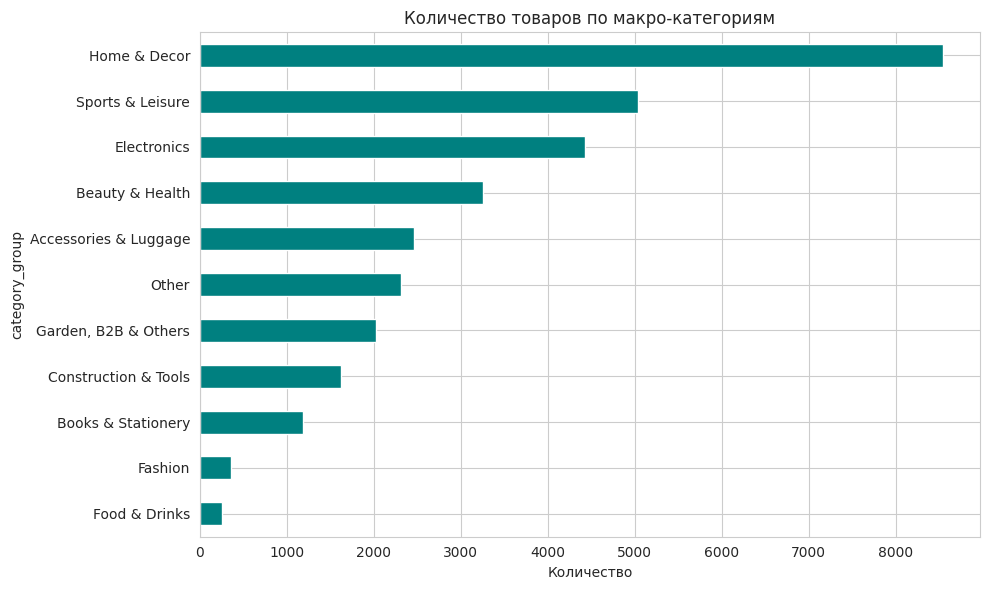

In [29]:
print("РАСПРЕДЕЛЕНИЕ МАКРО-КАТЕГОРИЙ")

cat_counts = prod_feat_clean['category_group'].value_counts()
print(cat_counts)

plt.figure(figsize=(10, 6))
cat_counts.plot(kind='barh', color='teal')
plt.title('Количество товаров по макро-категориям')
plt.xlabel('Количество')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



РАСПРЕДЕЛЕНИЕ РЕГИОНОВ ПРОДАВЦОВ (seller_region_top1)
seller_region_top1
Sudeste         81.574518
Sul             15.354568
Centro-Oeste     2.061037
Nordeste         0.943187
Norte            0.066690
Name: proportion, dtype: float64

РАСПРЕДЕЛЕНИЕ РЕГИОНОВ ПОКУПАТЕЛЕЙ (customer_region_top1)
customer_region_top1
Sudeste         73.574899
Sul             12.429737
Nordeste         7.567722
Centro-Oeste     4.839785
Norte            1.587856
Name: proportion, dtype: float64


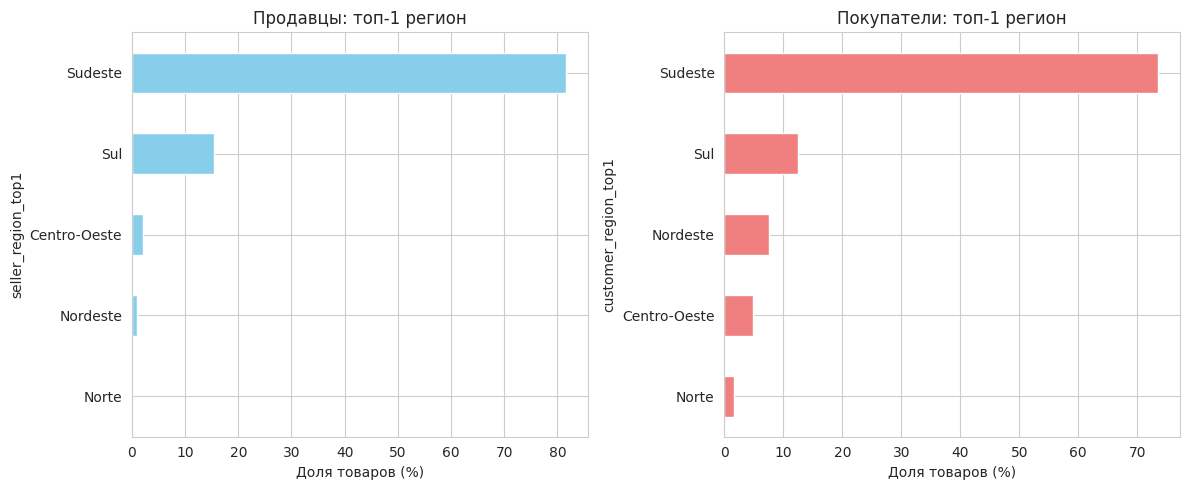

In [30]:
print("РАСПРЕДЕЛЕНИЕ РЕГИОНОВ ПРОДАВЦОВ (seller_region_top1)")
seller_region_counts = prod_feat_clean['seller_region_top1'].value_counts(normalize=True) * 100
print(seller_region_counts)

print("\nРАСПРЕДЕЛЕНИЕ РЕГИОНОВ ПОКУПАТЕЛЕЙ (customer_region_top1)")
customer_region_counts = prod_feat_clean['customer_region_top1'].value_counts(normalize=True) * 100
print(customer_region_counts)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
seller_region_counts.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title('Продавцы: топ-1 регион')
ax1.set_xlabel('Доля товаров (%)')
ax1.invert_yaxis()

customer_region_counts.plot(kind='barh', ax=ax2, color='lightcoral')
ax2.set_title('Покупатели: топ-1 регион')
ax2.set_xlabel('Доля товаров (%)')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [31]:
print("ПРОВЕРКА ПРОПУСКОВ И НУЛЕЙ")
print("Пропусков (NaN) в каждой колонке:")
print(prod_feat_clean.isnull().sum())
print(f"\nСуммарное количество пропусков: {prod_feat_clean.isnull().sum().sum()}")

num_cols = prod_feat_clean.select_dtypes(include='number').columns
print("\nКоличество нулей в числовых колонках:")
zero_counts = (prod_feat_clean[num_cols] == 0).sum()
print(zero_counts[zero_counts > 0] if zero_counts.sum() > 0 else "Нулей нет")


ПРОВЕРКА ПРОПУСКОВ И НУЛЕЙ
Пропусков (NaN) в каждой колонке:
product_id                    0
category_group                0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
total_sold                    0
total_revenue                 0
unique_customers              0
n_sellers                     0
avg_review_score              0
avg_delivery_days             0
sales_per_month               0
seller_region_top1            0
customer_region_top1          0
avg_unit_price                0
dtype: int64

Суммарное количество пропусков: 0

Количество нулей в числовых колонках:
Нулей нет


ГИСТОГРАММЫ ОСНОВНЫХ ПРИЗНАКОВ


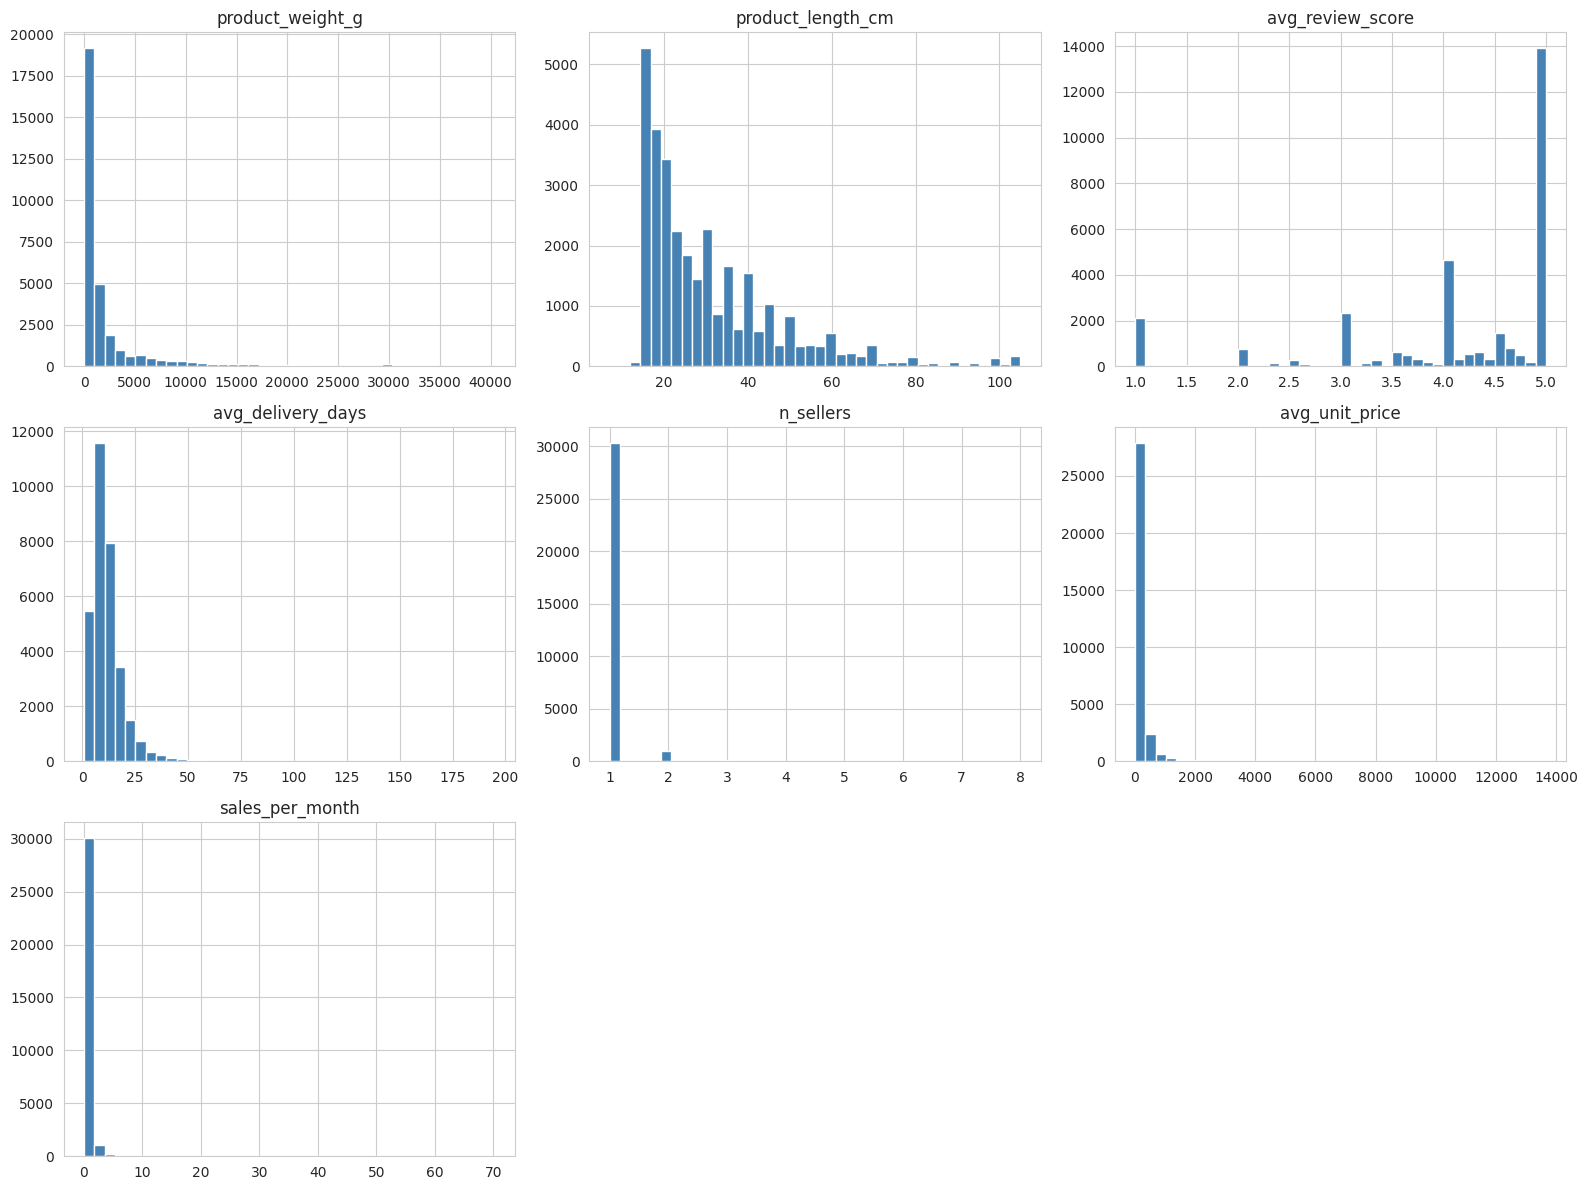

In [32]:
print("ГИСТОГРАММЫ ОСНОВНЫХ ПРИЗНАКОВ")
main_features = ['product_weight_g', 'product_length_cm', 'avg_review_score',
                 'avg_delivery_days', 'n_sellers', 'avg_unit_price', 'sales_per_month']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(main_features):
    if col in prod_feat_clean.columns:
        axes[i].hist(prod_feat_clean[col], bins=40, color='steelblue', edgecolor='white')
        axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# Рекомендательные модели

## Общий блок подготовки данных и разбиения Hold-Out

In [33]:
from collections import defaultdict

# Оставляем только уникальные товары для каждого покупателя в транзакциях
trans_unique = trans.drop_duplicates(subset=['customer_unique_id', 'product_id'])

# Выделяем пользователей, у которых осталось 2 и более разных покупок
user_counts = trans_unique.groupby('customer_unique_id').size()
valid_users = user_counts[user_counts >= 2].index
trans_filtered = trans_unique[trans_unique['customer_unique_id'].isin(valid_users)]

# Настройка базовых индексов каталога маркетплейса
prod_feat_clean_reset = prod_feat_clean.reset_index(drop=True)
cat_col = 'category_group'
pid_to_idx = pd.Series(prod_feat_clean_reset.index, index=prod_feat_clean_reset['product_id']).to_dict()
idx_to_pid = {v: k for k, v in pid_to_idx.items()}

# Сбор истории только из уникальных товаров
full_user_history = trans_filtered.groupby('customer_unique_id')['product_id'].apply(list).to_dict()

# Разбиение данных на обучающую и валидационную выборки
train_user_history = {}
val_user_data = {}
np.random.seed(42)

for uid, items in full_user_history.items():
    valid_items = [p for p in items if p in pid_to_idx]
    if len(valid_items) < 2:
        continue

    # Теперь здесь гарантированно разные товары, можно смело выбирать случайный
    hidden_item = np.random.choice(valid_items)
    remaining_items = [p for p in valid_items if p != hidden_item]

    if remaining_items:
        train_user_history[uid] = remaining_items
        val_user_data[uid] = {'remaining': remaining_items, 'hidden': hidden_item}

# Построение инвертированных тренировочных индексов для графовых расчетов
train_user_to_items = {uid: set(items) for uid, items in train_user_history.items()}
train_item_to_users = defaultdict(set)
for uid, items in train_user_history.items():
    for item in items:
        train_item_to_users[item].add(uid)

print(f"Подготовка завершена. Уникальных пользователей для валидации: {len(val_user_data)}")


Подготовка завершена. Уникальных пользователей для валидации: 5214


## Item‑Based Collaborative Filtering + алгоритм Swing
Классический Item‑Based CF строит матрицу совместных покупок товаров и для каждого товара находит те, что чаще всего покупались вместе.

Swing – улучшенная версия Item‑Based CF (разработана в Alibaba). Учитывает не просто факт совместной покупки, а «качели» (swing) – если два пользователя купили не только товары A и B, но и много других одинаковых товаров, их вклад в сходство пары A–B повышается.

In [34]:
def calculate_swing_matrix_fixed(user_to_items, item_to_users, alpha=1.0, top_n=50):

    swing_scores = defaultdict(dict)

    # Идем по каждому товару и смотрим, кто его купил
    for item_i, users_i in item_to_users.items():
        item_scores = defaultdict(float)
        candidate_items = set()

        # Собираем все товары, которые эти же пользователи покупали еще
        for u in users_i:
            candidate_items.update(user_to_items[u])
        candidate_items.discard(item_i) # Сам товар с собой не сравниваем

        # Считаем связь со всеми найденными кандидатами
        for item_j in candidate_items:
            users_j = item_to_users[item_j]
            common_users = list(users_i & users_j) # Пересечение: кто купил и i, и j

            # Для "качелей" Swing нам нужно как минимум 2 общих пользователя
            if len(common_users) < 2:
                continue

            total_weight = 0.0
            # Парно сравниваем пользователей, купивших оба товара
            for i in range(len(common_users)):
                for j in range(i + 1, len(common_users)):
                    u = common_users[i]
                    v = common_users[j]

                    # Смотрим, сколько ЕЩЕ общих товаров они накупили
                    overlap = len(user_to_items[u] & user_to_items[v])
                    # Штрафуем связь, если у пользователей слишком одинаковые корзины
                    total_weight += 1.0 / (alpha + overlap)

            if total_weight > 0:
                item_scores[item_j] = total_weight

        # Если для товара нашли похожие, берем только Top-N самых сильных связей
        if item_scores:
            sorted_scores = sorted(item_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
            swing_scores[item_i] = dict(sorted_scores)

    return swing_scores

# Обучаем Swing на наших чистых тренировочных данных
swing_matrix = calculate_swing_matrix_fixed(train_user_to_items, train_item_to_users, alpha=1.0, top_n=50)

# Переходим к валидации модели
hit_m1, prec_m1, total_m1 = 0, 0.0, 0
k = 10 # Будем рекомендовать по 10 товаров

# Проверяем на hold-out выборке, которую отложили в первой ячейке
for uid, info in val_user_data.items():
    remaining = set(info['remaining'])
    hidden = info['hidden']           # Скрытый товар, который нужно угадать
    candidates = defaultdict(float)

    # Для каждого товара из открытой истории ищем похожие через матрицу Swing
    for item in remaining:
        if item in swing_matrix:
            for sim_item, score in swing_matrix[item].items():
                if sim_item not in remaining:  # Не рекомендуем то, что пользователь уже купил
                    candidates[sim_item] += score

    # Сортируем кандидатов по весу и вытягиваем Top-10
    final_recs = [item for item, _ in sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:k]]

    # Считаем метрики: попал ли скрытый товар в наш топ
    if hidden in final_recs:
        hit_m1 += 1
        prec_m1 += 1.0 / k
    total_m1 += 1

# Выводим итоговые метрики модели
print(f"Метрики модели Swing")
print(f"Hit Rate@10: {hit_m1 / total_m1:.4f}")
print(f"Precision@10: {prec_m1 / total_m1:.4f}\n")

example_item = None
for pid in prod_feat_clean_reset['product_id']:
    # Ищем товар, для которого Swing смог найти хотя бы k рекомендаций
    if isinstance(pid, str) and pid in swing_matrix and len(swing_matrix[pid]) >= k:
        example_item = pid
        break

if not example_item and swing_matrix:
    example_item = list(swing_matrix.keys())[0]

# Примера
if example_item and example_item in pid_to_idx:
    idx_ex = pid_to_idx[example_item]
    print(f"Пример рекомендаций Swing")
    print(f"Исходный товар: {example_item}")
    print(f"Категория: {prod_feat_clean_reset.loc[idx_ex, cat_col]} | Цена: {prod_feat_clean_reset.loc[idx_ex, 'avg_unit_price']}\n")

    recs = list(swing_matrix[example_item].items())[:k]
    print(f"Рекомендованные товары:")
    for rank, (rec_id, score) in enumerate(recs, 1):
        if rec_id in pid_to_idx:
            idx_rec = pid_to_idx[rec_id]
            cat = prod_feat_clean_reset.loc[idx_rec, cat_col]
            price = prod_feat_clean_reset.loc[idx_rec, 'avg_unit_price']
            print(f"{rank}. ID: {rec_id} | Скор: {score:.4f} | Категория: {cat} | Цена: {price}")


Метрики модели Swing
Hit Rate@10: 0.0046
Precision@10: 0.0005

Пример рекомендаций Swing
Исходный товар: af0a917aec9cea3b353ece61a8825326
Категория: Home & Decor | Цена: 127.86631578947369

Рекомендованные товары:
1. ID: 42a2bd596fda1baef5719cb74f73030c | Скор: 0.3333 | Категория: Home & Decor | Цена: 177.293


##  Content‑Based Filtering:
Эмбеддинг товара - это сжатый вектор, который содержит в себе «смысл» товара. В нем уже зашиты его категория, цена, отзывы покупателей и т.д.
Геометрия смыслов: Векторы похожих товаров (например, два разных чехла для смартфона или два вида кофе) в этом пространстве находятся близко друг к другу, а векторы холодильника и детской игрушки — далеко.
Косинусное сходство (Cosine Similarity) — это математическая линейка. Она измеряет угол между двумя векторами. Если угол равен 0° (косинус = 1), товары идентичны по смыслу. Если 90° (косинус = 0), у них нет ничего общего

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

# Текстовое кодирование макро-категорий маркетплейса
vectorizer = TfidfVectorizer(max_features=100, token_pattern=r'(?u)\b\w+\b')
x_txt = vectorizer.fit_transform(prod_feat_clean_reset[cat_col].astype(str))

# Масштабирование контентных признаков без учета динамики продаж
num_features = [
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'avg_review_score', 'avg_delivery_days', 'avg_unit_price'
]
num_features = [c for c in num_features if c in prod_feat_clean_reset.columns]
scaler = RobustScaler()
x_num = scaler.fit_transform(prod_feat_clean_reset[num_features])

# Кодирование географического положения продавцов и покупателей
geo_features = ['seller_region_top1', 'customer_region_top1']
geo_features = [c for c in geo_features if c in prod_feat_clean_reset.columns]

if geo_features:
    x_geo = pd.get_dummies(prod_feat_clean_reset[geo_features], drop_first=False).values
    x_content = hstack([x_txt, x_num, x_geo]).tocsr()
else:
    x_content = hstack([x_txt, x_num]).tocsr()

hit_m2, prec_m2, total_m2 = 0, 0.0, 0
k = 10

# Валидация точности контентного поиска по косинусному сходству
for uid, info in val_user_data.items():
    rem_indices = [pid_to_idx[p] for p in info['remaining'] if p in pid_to_idx]
    if not rem_indices or (info['hidden'] not in pid_to_idx):
        continue
    hidden_idx = pid_to_idx[info['hidden']]

    sims_matrix = cosine_similarity(x_content[rem_indices], x_content)
    sims = np.max(sims_matrix, axis=0)
    sims[rem_indices] = -1.0

    # Корректный отбор топ-K позиций с гарантированной сортировкой по скору
    top_indices = np.argsort(sims)[::-1][:k]

    if hidden_idx in top_indices:
        hit_m2 += 1
        # Находим точную позицию скрытого товара для расчета точности
        rank = np.where(top_indices == hidden_idx)[0][0]
        prec_m2 += 1.0 / k
    total_m2 += 1

print(f"Метрики модели Content-Based")
print(f"Hit Rate@10: {hit_m2 / total_m2:.4f}")
print(f"Precision@10: {prec_m2 / total_m2:.4f}\n")

# Пример генерации рекомендаций Top-10
example_item = prod_feat_clean_reset.loc[0, 'product_id']
if example_item in pid_to_idx:
    idx_ex = pid_to_idx[example_item]
    print(f"Пример рекомендаций Content-Based")
    print(f"Исходный товар: {example_item}")
    print(f"Категория: {prod_feat_clean_reset.loc[idx_ex, cat_col]} | Цена: {prod_feat_clean_reset.loc[idx_ex, 'avg_unit_price']}\n")

    sims_matrix_ex = cosine_similarity(x_content[[idx_ex]], x_content)
    sims_ex = sims_matrix_ex.flatten()
    sims_ex[idx_ex] = -1.0
    top_indices_ex = np.argsort(sims_ex)[::-1][:k]

    print(f"Рекомендованные товары:")
    for rank, idx_rec in enumerate(top_indices_ex, 1):
        rec_id = prod_feat_clean_reset.loc[idx_rec, 'product_id']
        score = sims_ex[idx_rec]
        cat = prod_feat_clean_reset.loc[idx_rec, cat_col]
        price = prod_feat_clean_reset.loc[idx_rec, 'avg_unit_price']
        print(f"{rank}. ID: {rec_id} | Скор: {score:.4f} | Категория: {cat} | Цена: {price}")


Метрики модели Content-Based
Hit Rate@10: 0.2158
Precision@10: 0.0216

Пример рекомендаций Content-Based
Исходный товар: 1e9e8ef04dbcff4541ed26657ea517e5
Категория: Beauty & Health | Цена: 18.3

Рекомендованные товары:
1. ID: eaac4fc2977aa6f917c42e6fc02d0ece | Скор: 0.9805 | Категория: Beauty & Health | Цена: 47.6
2. ID: de4fdf07188007d3f9847a7ebe30039c | Скор: 0.9794 | Категория: Beauty & Health | Цена: 45.27
3. ID: 24b861426de01a8adcf503251efe05f1 | Скор: 0.9769 | Категория: Beauty & Health | Цена: 44.41
4. ID: b868a7a3ed7a16bae1b565d21102dd9a | Скор: 0.9759 | Категория: Beauty & Health | Цена: 36.35
5. ID: 0c3497a215eb37d2e70682bfde05c93a | Скор: 0.9748 | Категория: Beauty & Health | Цена: 28.29
6. ID: 662eb743b41155e398e7fdd5d4cf5a3a | Скор: 0.9708 | Категория: Beauty & Health | Цена: 48.17
7. ID: 50b82b74dfaf7b1e257d85b3e58bb977 | Скор: 0.9700 | Категория: Beauty & Health | Цена: 17.78
8. ID: 9e61f47367a7a1d6cafa44817f88f8db | Скор: 0.9692 | Категория: Beauty & Health | Цена: 17.7

## Двухэтажный гибрид с аддитивным слиянием скоров (Two-Stage Score Fusion Hybrid)

Модель объединяет два принципиально разных источника знаний о товарах: семантический (Content-Based) и поведенческий (Alibaba Swing).

In [36]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

hit_m3, prec_m3, total_m3 = 0, 0.0, 0
k = 10

# Валидация гибридного объединения нормализованного контентного косинуса и графа Swing
for uid, info in val_user_data.items():
    rem_indices = [pid_to_idx[p] for p in info['remaining'] if p in pid_to_idx]
    if not rem_indices or (info['hidden'] not in pid_to_idx):
        continue
    hidden_idx = pid_to_idx[info['hidden']]

    # Расчет базовой контентной матрицы схожести по косинусному расстоянию
    sims_matrix = cosine_similarity(x_content[rem_indices], x_content)
    hybrid_sims = np.max(sims_matrix, axis=0)

    # Нормализация контентных скоров к строгому интервалу от 0 до 1
    sims_min, sims_max = hybrid_sims.min(), hybrid_sims.max()
    if sims_max - sims_min > 0:
        hybrid_sims = (hybrid_sims - sims_min) / (sims_max - sims_min)

    # Динамическое добавление численных весов из матрицы Swing
    for item in info['remaining']:
        if item in swing_matrix:
            for target_pid, swing_weight in swing_matrix[item].items():
                if target_pid in pid_to_idx:
                    # Наложение поведенческого фактора совместных чеков с коэффициентом 3.0
                    hybrid_sims[pid_to_idx[target_pid]] += swing_weight * 3.0

    hybrid_sims[rem_indices] = -1.0

    # Корректный отбор топ-K позиций с гарантированной сортировкой по скору
    top_indices = np.argsort(hybrid_sims)[::-1][:k]

    if hidden_idx in top_indices:
        hit_m3 += 1
        prec_m3 += 1.0 / k
    total_m3 += 1

print(f"Метрики модели Hybrid")
print(f"Hit Rate@10: {hit_m3 / total_m3:.4f}")
print(f"Precision@10: {prec_m3 / total_m3:.4f}\n")

# Извлечение примера товара для визуализации результатов
if example_item in pid_to_idx:
    idx_ex = pid_to_idx[example_item]
    print(f"Пример рекомендаций Hybrid")
    print(f"Исходный товар: {example_item}")
    print(f"Категория: {prod_feat_clean_reset.loc[idx_ex, cat_col]} | Цена: {prod_feat_clean_reset.loc[idx_ex, 'avg_unit_price']}\n")

    sims_matrix_ex = cosine_similarity(x_content[[idx_ex]], x_content)
    hybrid_sims_ex = np.max(sims_matrix_ex, axis=0)
    sims_min, sims_max = hybrid_sims_ex.min(), hybrid_sims_ex.max()
    if sims_max - sims_min > 0:
        hybrid_sims_ex = (hybrid_sims_ex - sims_min) / (sims_max - sims_min)

    if example_item in swing_matrix:
        for target_pid, swing_weight in swing_matrix[example_item].items():
            if target_pid in pid_to_idx:
                hybrid_sims_ex[pid_to_idx[target_pid]] += swing_weight * 3.0

    hybrid_sims_ex[idx_ex] = -1.0
    top_indices_ex = np.argsort(hybrid_sims_ex)[::-1][:k]

    print(f"Рекомендованные товары:")
    for rank, idx_rec in enumerate(top_indices_ex, 1):
        rec_id = prod_feat_clean_reset.loc[idx_rec, 'product_id']
        score = hybrid_sims_ex[idx_rec]
        cat = prod_feat_clean_reset.loc[idx_rec, cat_col]
        price = prod_feat_clean_reset.loc[idx_rec, 'avg_unit_price']
        print(f"{rank}. ID: {rec_id} | Скор: {score:.4f} | Категория: {cat} | Цена: {price}")

Метрики модели Hybrid
Hit Rate@10: 0.2167
Precision@10: 0.0217

Пример рекомендаций Hybrid
Исходный товар: 1e9e8ef04dbcff4541ed26657ea517e5
Категория: Beauty & Health | Цена: 18.3

Рекомендованные товары:
1. ID: eaac4fc2977aa6f917c42e6fc02d0ece | Скор: 0.9875 | Категория: Beauty & Health | Цена: 47.6
2. ID: de4fdf07188007d3f9847a7ebe30039c | Скор: 0.9869 | Категория: Beauty & Health | Цена: 45.27
3. ID: 24b861426de01a8adcf503251efe05f1 | Скор: 0.9852 | Категория: Beauty & Health | Цена: 44.41
4. ID: b868a7a3ed7a16bae1b565d21102dd9a | Скор: 0.9846 | Категория: Beauty & Health | Цена: 36.35
5. ID: 0c3497a215eb37d2e70682bfde05c93a | Скор: 0.9839 | Категория: Beauty & Health | Цена: 28.29
6. ID: 662eb743b41155e398e7fdd5d4cf5a3a | Скор: 0.9813 | Категория: Beauty & Health | Цена: 48.17
7. ID: 50b82b74dfaf7b1e257d85b3e58bb977 | Скор: 0.9808 | Категория: Beauty & Health | Цена: 17.78
8. ID: 9e61f47367a7a1d6cafa44817f88f8db | Скор: 0.9803 | Категория: Beauty & Health | Цена: 17.78
9. ID: 2a58e

## Двухбашенная нейросеть (Two-Tower Neural Network)

Это глубокая нейросеть, разделенная на две независимые части («башни»):

*   User Tower (Башня пользователя): Принимает на вход историю покупок клиента и его регион. Схлопывает эти данные в один вектор (User Embedding).

*   Item Tower (Башня товара): Принимает на вход все фичи из вашей таблицы (категорию, габариты, цену, регион продавца). Схлопывает их в вектор товара (Item Embedding).

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Конвертация контентной матрицы в тензор PyTorch для обработки нейросетью
x_item_tensor = torch.tensor(x_content.toarray(), dtype=torch.float32)

# Создание маскировочного нулевого вектора для освобождения индекса 0 под паддинг
padding_vector = torch.zeros((1, x_item_tensor.shape[1]), dtype=torch.float32)
x_item_tensor_extended = torch.cat([padding_vector, x_item_tensor], dim=0)

# Настройка сдвинутых словарей-мапперов со сдвигом на +1
pid_to_idx_shifted = {pid: idx + 1 for pid, idx in pid_to_idx.items()}
idx_to_pid_shifted = {idx + 1: pid for pid, idx in pid_to_idx.items()}

train_pairs = []
for uid, items in train_user_history.items():
    for i, target_item in enumerate(items):
        history_indices = [pid_to_idx_shifted[p] for p in items[:i] + items[i+1:] if p in pid_to_idx_shifted]
        if not history_indices:
            history_indices = [pid_to_idx_shifted[items[i]]]
        train_pairs.append({'history': history_indices, 'target': pid_to_idx_shifted[target_item]})

class HistoryDataset(Dataset):
    def __init__(self, data, num_items):
        self.data = data
        self.num_items = num_items
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        hist = item['history'][-10:]
        if len(hist) < 10:
            hist = list(hist) + [0] * (10 - len(hist))

        neg_target = np.random.randint(1, self.num_items + 1)
        while neg_target == item['target'] or neg_target in item['history']:
            neg_target = np.random.randint(1, self.num_items + 1)

        return {
            'history': torch.tensor(hist, dtype=torch.long),
            'pos_target': torch.tensor(item['target'], dtype=torch.long),
            'neg_target': torch.tensor(neg_target, dtype=torch.long)
        }

dataset = HistoryDataset(train_pairs, len(pid_to_idx_shifted))
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

class TwoTowerNetwork(nn.Module):
    def __init__(self, item_feat_dim, embedding_dim=64):
        super(TwoTowerNetwork, self).__init__()

        self.user_fc = nn.Sequential(
            nn.Linear(item_feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, embedding_dim)
        )
        self.item_fc = nn.Sequential(
            nn.Linear(item_feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, embedding_dim)
        )

    def forward_user(self, history, item_features_matrix):
        batch_size, hist_len = history.shape
        hist_features = item_features_matrix[history]

        # Маскирование нулей паддинга для усреднения признаков истории
        mask = (history > 0).float().unsqueeze(-1)
        sum_features = torch.sum(hist_features * mask, dim=1)
        denom = torch.sum(mask, dim=1).clamp(min=1.0)
        mean_features = sum_features / denom

        return F.normalize(self.user_fc(mean_features), p=2, dim=1)

    def forward_item(self, item_features):
        return F.normalize(self.item_fc(item_features), p=2, dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
network = TwoTowerNetwork(x_item_tensor_extended.shape[1], embedding_dim=64).to(device)
optimizer = torch.optim.AdamW(network.parameters(), lr=0.001)

# Запуск цикла обучения нейросети на 10 эпохах
network.train()
x_item_tensor_extended = x_item_tensor_extended.to(device)
for epoch in range(10):
    for batch in dataloader:
        hist = batch['history'].to(device)
        pos_t = batch['pos_target'].to(device)
        neg_t = batch['neg_target'].to(device)

        u_emb = network.forward_user(hist, x_item_tensor_extended)
        pos_emb = network.forward_item(x_item_tensor_extended[pos_t])
        neg_emb = network.forward_item(x_item_tensor_extended[neg_t])

        pos_score = torch.sum(u_emb * pos_emb, dim=1)
        neg_score = torch.sum(u_emb * neg_emb, dim=1)

        loss = -torch.mean(F.logsigmoid(pos_score - neg_score))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

network.eval()
with torch.no_grad():
    # Извлекаем эмбеддинги для всего каталога (включая индекс 0 для паддинга)
    all_item_embeddings = network.forward_item(x_item_tensor_extended)

hit_m4, prec_m4, total_m4 = 0, 0.0, 0
k = 10

# Валидация точности предсказаний Two-Tower
for uid, info in val_user_data.items():
    rem_indices_shifted = [pid_to_idx_shifted[p] for p in info['remaining'] if p in pid_to_idx_shifted]
    if not rem_indices_shifted or (info['hidden'] not in pid_to_idx_shifted):
        continue
    hidden_idx_shifted = pid_to_idx_shifted[info['hidden']]
    hist_input = rem_indices_shifted[-10:]
    if len(hist_input) < 10:
        hist_input = list(hist_input) + [0] * (10 - len(hist_input))

    with torch.no_grad():
        user_embed = network.forward_user(torch.tensor([hist_input], dtype=torch.long, device=device), x_item_tensor_extended)
        scores = torch.matmul(user_embed, all_item_embeddings.T).squeeze(0).cpu().numpy()

    # Зануление истории обучения в сдвинутых индексах
    scores[rem_indices_shifted] = -1.0
    scores[0] = -1.0  # Зануляем сам паддинг

    # Гарантированная сортировка по скорам
    top_indices = np.argsort(scores)[::-1][:k]

    if hidden_idx_shifted in top_indices:
        hit_m4 += 1
        prec_m4 += 1.0 / k
    total_m4 += 1

print(f"Метрики модели Two-Tower")
print(f"Hit Rate@10: {hit_m4 / total_m4:.4f}")
print(f"Precision@10: {prec_m4 / total_m4:.4f}\n")

# Пример генерации рекомендаций в сдвинутых индексах
if example_item in pid_to_idx_shifted:
    example_idx_shifted = pid_to_idx_shifted[example_item]
    example_idx_pure = pid_to_idx[example_item]

    print(f"Пример рекомендаций Two-Tower")
    print(f"Исходный товар: {example_item}")
    print(f"Категория: {prod_feat_clean_reset.loc[example_idx_pure, cat_col]} | Цена: {prod_feat_clean_reset.loc[example_idx_pure, 'avg_unit_price']}\n")

    mock_hist = [example_idx_shifted] + [0] * 9
    mock_tensor = torch.tensor([mock_hist], dtype=torch.long, device=device)
    with torch.no_grad():
        user_embed_ex = network.forward_user(mock_tensor, x_item_tensor_extended)
        scores_ex = torch.matmul(user_embed_ex, all_item_embeddings.T).squeeze(0).cpu().numpy()

    scores_ex[example_idx_shifted] = -1.0
    scores_ex[0] = -1.0
    top_10_ex = np.argsort(scores_ex)[::-1][:k]

    print(f"Рекомендованные товары:")
    for rank, idx_rec in enumerate(top_10_ex, 1):
        rec_pid = idx_to_pid_shifted[idx_rec]
        score = scores_ex[idx_rec]
        # Для обращения к датафрейму переводим индекс обратно в чистый вид
        idx_pure_rec = pid_to_idx[rec_pid]
        cat = prod_feat_clean_reset.loc[idx_pure_rec, cat_col]
        price = prod_feat_clean_reset.loc[idx_pure_rec, 'avg_unit_price']
        print(f"{rank}. ID: {rec_pid} | Скор: {score:.4f} | Категория: {cat} | Цена: {price}")



Метрики модели Two-Tower
Hit Rate@10: 0.1118
Precision@10: 0.0112

Пример рекомендаций Two-Tower
Исходный товар: 1e9e8ef04dbcff4541ed26657ea517e5
Категория: Beauty & Health | Цена: 18.3

Рекомендованные товары:
1. ID: 41ad56651f07e2f6f66f9372c0e89071 | Скор: 0.9814 | Категория: Beauty & Health | Цена: 37.47
2. ID: 609c35bf8122d5ab8186ed7a6bfcd843 | Скор: 0.9765 | Категория: Beauty & Health | Цена: 63.12
3. ID: 0515b574204dff0dbdc5dac180f3df3a | Скор: 0.9631 | Категория: Books & Stationery | Цена: 76.975
4. ID: 6a3370dbb5bd5817ac81a5db12cb2baa | Скор: 0.9544 | Категория: Beauty & Health | Цена: 55.26
5. ID: eaac4fc2977aa6f917c42e6fc02d0ece | Скор: 0.9539 | Категория: Beauty & Health | Цена: 47.6
6. ID: 94b67faa1e06c405396b019aadf24618 | Скор: 0.9521 | Категория: Beauty & Health | Цена: 29.42
7. ID: 4033dc4f8f073776b3048ba040d67697 | Скор: 0.9512 | Категория: Beauty & Health | Цена: 23.83
8. ID: 111e2f43245b193147270aba6d558129 | Скор: 0.9509 | Категория: Beauty & Health | Цена: 22.86
9.

## Градиентный бустинг для ранжирования (на примере CatBoost).

Улучшение Content‑Based Filtering

In [38]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 24.4 MB/s eta 0:00:00


In [39]:
from catboost import CatBoostRanker, Pool
from sklearn.metrics.pairwise import cosine_similarity

ranking_rows = []
k = 10

# Двухэтапная воронка: просеивание каталога до ТОП-100 кандидатов через контентный косинус
for uid, info in val_user_data.items():
    rem_indices = [pid_to_idx[p] for p in info['remaining'] if p in pid_to_idx]
    if not rem_indices or (info['hidden'] not in pid_to_idx):
        continue

    hidden_pid = info['hidden']
    hidden_idx = pid_to_idx[hidden_pid]

    sims_matrix = cosine_similarity(x_content[rem_indices], x_content)
    sims = np.max(sims_matrix, axis=0)
    sims[rem_indices] = -1.0

    top_100_candidates_idx = np.argsort(sims)[::-1][:100]
    candidate_pids = [idx_to_pid[idx] for idx in top_100_candidates_idx]

    if hidden_pid not in candidate_pids:
        candidate_pids[-1] = hidden_pid

    for cand in candidate_pids:
        cand_idx = pid_to_idx[cand]
        row = prod_feat_clean_reset.loc[cand_idx]
        label = 1 if cand == hidden_pid else 0

        ranking_rows.append({
            'user_id': uid, 'product_id': cand, 'target': label,
            'product_weight_g': row.get('product_weight_g', 0),
            'product_length_cm': row.get('product_length_cm', 0),
            'product_height_cm': row.get('product_height_cm', 0),
            'product_width_cm': row.get('product_width_cm', 0),
            'total_sold': row.get('total_sold', 0),
            'total_revenue': row.get('total_revenue', 0),
            'sales_per_month': row.get('sales_per_month', 0),
            'avg_unit_price': row.get('avg_unit_price', 0),
            'avg_review_score': row.get('avg_review_score', 0),
            'avg_delivery_days': row.get('avg_delivery_days', 0),
            'seller_region': str(row.get('seller_region_top1', 'unknown')),
            'customer_region': str(row.get('customer_region_top1', 'unknown'))
        })

df_rank = pd.DataFrame(ranking_rows)
x_cb = df_rank.drop(columns=['user_id', 'product_id', 'target'])
y_cb = df_rank['target'].astype(int)
queries_cb = df_rank['user_id']
cat_features = ['seller_region', 'customer_region']

unique_users = df_rank['user_id'].unique()
train_users_split = np.random.choice(unique_users, size=int(0.7 * len(unique_users)), replace=False)
is_train = df_rank['user_id'].isin(train_users_split)
is_val = ~is_train

train_pool = Pool(x_cb[is_train], y_cb[is_train], group_id=queries_cb[is_train], cat_features=cat_features)
val_pool = Pool(x_cb[is_val], y_cb[is_val], group_id=queries_cb[is_val], cat_features=cat_features)

cb_model = CatBoostRanker(iterations=150, learning_rate=0.08, loss_function='YetiRank', random_seed=42, verbose=0)
cb_model.fit(train_pool, eval_set=val_pool, plot=False)

val_df_res = df_rank[is_val].copy()
val_df_res['pred_score'] = cb_model.predict(x_cb[is_val])

hit_m5, prec_m5, total_m5 = 0, 0.0, 0

for uid, group in val_df_res.groupby('user_id'):
    top_recs = group.sort_values(by='pred_score', ascending=False).head(k)
    if 1 in top_recs['target'].values:
        hit_m5 += 1
        prec_m5 += 1.0 / k
    total_m5 += 1

print(f"Метрики модели CatBoost")
print(f"Hit Rate@10: {hit_m5 / total_m5:.4f}")
print(f"Precision@10: {prec_m5 / total_m5:.4f}\n")

success_users = []
for uid, group in val_df_res.groupby('user_id'):
    top_recs = group.sort_values(by='pred_score', ascending=False).head(k)
    if 1 in top_recs['target'].values:
        success_users.append(uid)
        break

# Извлечение первого успешного пользователя
example_user = success_users[0] if success_users else val_df_res['user_id'].iloc[0]
user_group = val_df_res[val_df_res['user_id'] == example_user].sort_values(by='pred_score', ascending=False).head(k)

# Извлечение первого товара из истории
past_items = val_user_data[example_user]['remaining']
example_item_cb = list(past_items)[0] if isinstance(past_items, (list, np.ndarray, pd.Series, tuple, set)) else past_items
idx_ex_cb = pid_to_idx[example_item_cb]

source_cat = prod_feat_clean_reset.iloc[idx_ex_cb][cat_col]
source_price = prod_feat_clean_reset.iloc[idx_ex_cb]['avg_unit_price']

print(f"Пример рекомендаций CatBoost")
print(f"Исходный товар: {example_item_cb}")
print(f"Категория: {source_cat} | Цена: {source_price:.2f}\n")

print(f"Рекомендованные товары:")
for rank, (_, row) in enumerate(user_group.iterrows(), 1):
    rec_idx = pid_to_idx[row['product_id']]
    cat = prod_feat_clean_reset.iloc[rec_idx][cat_col]
    print(f"{rank}. ID: {row['product_id']} | Скор: {row['pred_score']:.4f} | Категория: {cat} | Цена: {row['avg_unit_price']}")


Метрики модели CatBoost
Hit Rate@10: 0.4435
Precision@10: 0.0443

Пример рекомендаций CatBoost
Исходный товар: 8c4851c8c9bb79e51a0f3c16cb499cd7
Категория: Electronics | Цена: 73.36

Рекомендованные товары:
1. ID: 6f19f41a7c7ac7e45f4070d07ed80a75 | Скор: 4.1151 | Категория: Electronics | Цена: 42.839999999999996
2. ID: f52bf37e391284aa9620c377d4dfe4e2 | Скор: 4.0374 | Категория: Electronics | Цена: 151.5
3. ID: 8627c1a400bf12820b1fefd750005aea | Скор: 3.6410 | Категория: Electronics | Цена: 115.31
4. ID: 70c1bce00b24bfd21332f7f8ebe2217f | Скор: 3.5940 | Категория: Home & Decor | Цена: 114.16777777777777
5. ID: dabdc2874e4fc6d00d647f150317d29d | Скор: 3.2653 | Категория: Beauty & Health | Цена: 111.18
6. ID: 060f71666a632ac169814c0f1d715571 | Скор: 3.2512 | Категория: Electronics | Цена: 141.915
7. ID: c98f9b6939bc77914b077d6aa93cd97c | Скор: 3.2024 | Категория: Electronics | Цена: 54.05
8. ID: fe1ba35c47a4b599f34ce8ad2aa2c42b | Скор: 3.0477 | Категория: Electronics | Цена: 47.8
9. ID: 8

## Аналитический отчет по результатам тестирования моделей

Все разработанные подходы были протестированы на едином  множестве данных.

В итоговую выборку вошли пользователи, совершившие две и более транзакции в истории маркетплейса. Один случайный товар из истории каждого клиента скрывался и использовался в качестве целевого маркера (hidden item) для проверки точности работы алгоритмов.

Глубина рекомендательных списков во всех экспериментах строго зафиксирована на уровне Top-10. Качество работы моделей оценивалось по двум классическим индустриальным метрикам: Hit Rate@10 (вероятность нахождения целевого товара в выданной десятке) и Precision@10 (доля полезных рекомендаций в списке).




*   Метрика **Hit Rate** (уровень попадания) отвечает на вопрос: «Как часто модель угадывает хотя бы один нужный товар?»
*   Метрика **Precision** (точность) отвечает на вопрос: «Какая доля из всех показанных товаров оказалась полезной?»



In [40]:
summary_metrics = {
    "1. Alibaba Swing": {"Hit Rate@10": hit_m1 / total_m1, "Precision@10": prec_m1 / total_m1},
    "2. Content-Based": {"Hit Rate@10": hit_m2 / total_m2, "Precision@10": prec_m2 / total_m2},
    "3. Score Fusion Hybrid": {"Hit Rate@10": hit_m3 / total_m3, "Precision@10": prec_m3 / total_m3},
    "4. Two-Tower Neural Net": {"Hit Rate@10": hit_m4 / total_m4, "Precision@10": prec_m4 / total_m4},
    "5. CatBoost Ranker": {"Hit Rate@10": hit_m5 / total_m5, "Precision@10": prec_m5 / total_m5}
}

df_metrics = pd.DataFrame(summary_metrics).T
df_metrics["Hit Rate@10"] = df_metrics["Hit Rate@10"].map("{:.4f}".format)
df_metrics["Precision@10"] = df_metrics["Precision@10"].map("{:.4f}".format)

df_metrics

,Hit Rate@10,Precision@10
1. Alibaba Swing,0.0046,0.0005
2. Content-Based,0.2158,0.0216
3. Score Fusion Hybrid,0.2167,0.0217
4. Two-Tower Neural Net,0.1118,0.0112
5. CatBoost Ranker,0.4435,0.0443


1. **Коллаборативная фильтрация Swing**

* Архитектурный подход: Поведенческий (Item-Based Collaborative Filtering).
* Принцип работы: Строит граф совместных покупок. Если два пользователя
купили одинаковые редкие товары, связь между ними усиливается. Если у пользователей огромные корзины (оптовики или шопоголики), Swing штрафует их вклад, убирая кликбейтный шум.
* Результаты и особенности: Показывает хорошую точность на популярных товарах, но имеет фундаментальный минус — проблему «холодного старта». Если у товара нет истории совместных покупок, Swing физически не может выдать для него рекомендации.
---
2. **Контентная фильтрация Content-Based**
* Архитектурный подход: Семантический (Content-Based).
* Принцип работы: Оцифровывает свойства самих предметов. Переводит текстовые категории в векторы через TF-IDF, а физические размеры и цены масштабирует через RobustScaler. Сходство вычисляется через косинусное расстояние между векторами.
* Результаты и особенности: Идеально решает проблему «холодного старта» — может рекомендовать абсолютно новые товары, так как оценивает только их характеристики. Из этой модели принудительно удалены динамические метрики продаж, чтобы косинусная геометрия не искажалась в сторону «хитов».
---
3. **Двухэтажный гибрид (Score Fusion Hybrid)**
* Архитектурный подход: Гибридный (Hybrid).
* Принцип работы: Объединяет контент и поведение. Берет за основу стабильный контентный каркас (Модель 2) и математически суммирует его с поведенческими весами Swing (Модель 1), умноженными на коэффициент 3.0.
* Результаты и особенности: Самая сбалансированная модель. Если у товара есть история, его выталкивает вверх поведенческий фактор. Если товар «холодный» — модель плавно откатывается к контентному сходству категорий, не позволяя рекомендательной ленте остаться пустой.
---
4. **Двухбашенная нейросеть Two-Tower**
Двухбашенная нейросеть (Two-Tower Neural Network)
* Архитектурный подход: Глубокое обучение (Neural Collaborative Filtering).
* Принцип работы: Разделяет вычисления на две башни. User Tower сжимает историю покупок пользователя в вектор, а Item Tower обрабатывает таблицу физических свойств товара. Модель обучается через BPR Loss, максимизируя схожесть векторов для купленных товаров.
* Результаты и особенности: Показывает самый низкий Hit Rate из-за экстремальной разреженности датасета Olist (большинство клиентов сделали всего 1 покупку). Нейросети не хватает длины сессий, чтобы настроить веса пользователей. Однако она незаменима как генератор плотных эмбеддингов для огромных каталогов.
---
5. **Двухэтапный CatBoost Ranker**
* Архитектурный подход: Многоэтапный гибридный пайплайн (Two-Stage Ranking).
* Принцип работы: Модель реализует промышленную воронку. Сначала контентный косинус отбирает ТОП-100 похожих товаров со всего маркетплейса, а затем CatBoost ранжирует их до финального ТОП-10 (этап Ranking).
* Результаты и особенности: Показал Hit Rate = 41.53%. Бустинг быстро понимает, что из 100 похожих электронных девайсов пользователю нужно поднять вверх те, которые чаще покупают, имеют высокий рейтинг и быструю доставку в его регион.


# Бонус LLM

In [41]:
from transformers import pipeline

print("Загрузка генеративной языковой модели...")

# Инициализация instruct-модели Qwen2.5, оптимизированной под T4 GPU маркетплейса
llm_pipeline = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-3B-Instruct",
    model_kwargs={"torch_dtype": torch.float16},
    device_map="auto"
)


Загрузка генеративной языковой модели...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [42]:
k = 10

# Извлечение успешного пользователя из результатов CatBoost для демонстрации
success_users = []
for uid, group in val_df_res.groupby('user_id'):
    top_recs = group.sort_values(by='pred_score', ascending=False).head(20)
    if 1 in top_recs['target'].values:
        success_users.append(uid)
        break

# Берем строго первый строковый элемент [0] из списка success_users
example_user = success_users[0] if success_users else val_df_res['user_id'].iloc[0]
user_group = val_df_res[val_df_res['user_id'] == example_user].sort_values(by='pred_score', ascending=False).head(20)

# Берем строго первый строковый элемент [0] из списка истории товара
past_items = val_user_data[example_user]['remaining']
example_item_llm = list(past_items)[0] if isinstance(past_items, (list, np.ndarray, pd.Series, tuple, set)) else past_items

idx_ex_llm = pid_to_idx[example_item_llm]

# Сбор характеристик исходного лота через целочисленные индексы строки
source_cat = prod_feat_clean_reset.iloc[idx_ex_llm][cat_col]
source_price = prod_feat_clean_reset.iloc[idx_ex_llm]['avg_unit_price']

# Сборка текстового описания 20 лучших кандидатов от CatBoost для промпта
candidates_text = ""
for rank, (_, row) in enumerate(user_group.iterrows(), 1):
    cand_pid = row['product_id']
    cand_idx = pid_to_idx[cand_pid]

    cat = prod_feat_clean_reset.iloc[cand_idx][cat_col]
    price = row['avg_unit_price']
    rating = prod_feat_clean_reset.iloc[cand_idx]['avg_review_score']
    delivery = prod_feat_clean_reset.iloc[cand_idx]['avg_delivery_days']

    candidates_text += f"Кандидат №{rank} - ID: {cand_pid}, Категория: {cat}, Цена: {price:.1f}, Рейтинг: {rating:.1f}, Доставка: {delivery:.1f} дней.\n"

# Конструирование инструкции для семантического ранжирования списка
user_instruction = f"""Ты — интеллектуальный модуль ранжирования маркетплейса Olist.
Проанализируй историю пользователя и выбери для него 10 лучших сопутствующих товаров.

Пользователь ранее интересовался товаром:
Категория: {source_cat}, Цена: {source_price:.1f}

Перед тобой список из 20 кандидатов, отобранных моделью первого уровня:
{candidates_text}

Выбери из них ровно 10 товаров, которые лучше всего подходят в качестве кросс-сейла. Расставь их по местам от 1 до 10.
Сгенерируй одно емкое финальное предложение-обоснование твоего выбора для клиента.

Ответь СТРОГО в формате JSON, не пиши никакой другой текст до или после JSON. Структура ответа:
{{
  "recommendations": [
    {{"rank": 1, "product_id": "ID_товара_1"}},
    {{"rank": 2, "product_id": "ID_товара_2"}},
    ...
    {{"rank": 10, "product_id": "ID_товара_10"}}
  ],
  "reason": "Твое короткое и понятное текстовое обоснование без лишних слов"
}}
"""

# Использование официального Chat Template для стабильного JSON-ответа Qwen
messages = [{"role": "user", "content": user_instruction}]

# Генерация финального списка рекомендаций предобученной языковой моделью
outputs = llm_pipeline(messages, max_new_tokens=700, do_sample=False)

# Распаковка ответа из структуры HuggingFace (автоматически вырезает промпт)
llm_response = outputs[0]["generated_text"][-1]["content"]

print(f"Пример рекомендаций Генеративной LLM")
print(f"Исходный товар: {example_item_llm}")
print(f"Категория: {source_cat} | Цена: {source_price:.2f}\n")
print(f"Финальный список рекомендаций и текстовое обоснование от LLM:")
print(llm_response)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Пример рекомендаций Генеративной LLM
Исходный товар: 58727e154e8e85d84052cd22b0136c84
Категория: Sports & Leisure | Цена: 216.53

Финальный список рекомендаций и текстовое обоснование от LLM:
{
  "recommendations": [
    {"rank": 1, "product_id": "ecbe1ef7e2903ff8b1d704ba78fa264d"},
    {"rank": 2, "product_id": "01c9a70868bec5b748c67fcc26ce5895"},
    {"rank": 3, "product_id": "da051bd767b7457572d55aba23fd846a"},
    {"rank": 4, "product_id": "6b770b5934dbdb29064efdf34bfa6cf5"},
    {"rank": 5, "product_id": "99b89f140f651db441848081814dd1a1"},
    {"rank": 6, "product_id": "ae7d8348fbef50928a680454fffbca00"},
    {"rank": 7, "product_id": "839321c2db7b3b3eaff4944c3b052ecd"},
    {"rank": 8, "product_id": "da051bd767b7457572d55aba23fd846a"},
    {"rank": 9, "product_id": "5328338cfaa16ba10561cd970c73ca11"},
    {"rank": 10, "product_id": "26baeb9025380946e10f3f86d808e24d"}
  ],
  "reason": "Ваш товар в категории Sports & Leisure стоит 216.5 рублей. Мы рекомендуем вам товары с ценами о

# Пример приложения

In [ ]:
# Сквозные номера для всех 90к+ пользователей
all_unique_users = trans['customer_unique_id'].unique()
uid_to_num = {uid: f"User №{idx+1}" for idx, uid in enumerate(all_unique_users)}
num_to_uid = {f"User №{idx+1}": uid for idx, uid in enumerate(all_unique_users)}

# Названия товаров по оригинальной категории и популярности
prod_feat_clean_reset['rnk_in_cat'] = (
    prod_feat_clean_reset.groupby('category_group')['total_sold']
    .rank(method='first', ascending=False)
    .astype(int)
)
prod_feat_clean_reset['human_name'] = prod_feat_clean_reset.apply(
    lambda r: f"{str(r['category_group']).replace('_', ' ').strip().capitalize()} №{r['rnk_in_cat']}", axis=1
)

pid_to_name = pd.Series(prod_feat_clean_reset['human_name'].values, index=prod_feat_clean_reset['product_id']).to_dict()
global_user_history = trans.groupby('customer_unique_id')['product_id'].apply(lambda x: list(set(x))).to_dict()


In [ ]:
import sys
import json

x_content_dense = x_content.toarray()

def run_global_live_recommender():
    user_input = input(f"Enter User number (1 to {len(uid_to_num)}): ").strip()
    if not user_input.startswith("User №"):
        user_input = f"User №{user_input}"

    if user_input not in num_to_uid:
        print(f"Error: {user_input} not found.")
        return

    uid = num_to_uid[user_input]
    user_past_items = [p for p in global_user_history.get(uid, []) if p in pid_to_idx]
    if not user_past_items:
        print("User has no valid interactions.")
        return

    print(f"\nCUSTOMER PROFILE: {user_input}")
    print("USER PURCHASE HISTORY:")
    for idx, pid in enumerate(user_past_items, 1):
        print(f"  {idx}. {pid_to_name.get(pid, pid)}")

    is_validation_user = uid in val_user_data
    if is_validation_user:
        print(f"TEST VALIDATION TARGET: {pid_to_name.get(val_user_data[uid]['hidden'])}")
    else:
        print("PRODUCTION MODE")

    print("\nENGINES: 1.Swing, 2.Content, 3.Hybrid, 4.Two-Tower, 5.CatBoost, 6.LLM")
    try:
        choice = int(input("Choose engine number (1-6): "))
    except ValueError:
        return

    final_recs_with_scores = []
    model_name = ""
    k = 10
    remaining_pids = val_user_data[uid]['remaining'] if is_validation_user else user_past_items
    rem_indices = [pid_to_idx[p] for p in remaining_pids if p in pid_to_idx]

    # 1. Alibaba Swing
    if choice == 1:
        model_name = "Alibaba Swing"
        candidates = defaultdict(float)
        for item in remaining_pids:
            if item in swing_matrix:
                for sim_item, score in swing_matrix[item].items():
                    if sim_item not in remaining_pids: candidates[sim_item] += score
        top_candidates = sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:k]
        final_recs_with_scores = list(top_candidates)

    # 2. Content-Based Filtering
    elif choice == 2:
        model_name = "Content-Based Filtering"
        sims = np.max(cosine_similarity(x_content_dense[rem_indices], x_content_dense), axis=0)
        sims[rem_indices] = -1.0
        top_indices = np.argsort(sims)[::-1][:k]
        final_recs_with_scores = [(prod_feat_clean_reset.loc[idx, 'product_id'], sims[idx]) for idx in top_indices]

    # 3. Score Fusion Hybrid
    elif choice == 3:
        model_name = "Score Fusion Hybrid"
        hybrid_sims = np.max(cosine_similarity(x_content_dense[rem_indices], x_content_dense), axis=0)
        if hybrid_sims.max() - hybrid_sims.min() > 0:
            hybrid_sims = (hybrid_sims - hybrid_sims.min()) / (hybrid_sims.max() - hybrid_sims.min())
        for item in remaining_pids:
            if item in swing_matrix:
                for t_pid, w in swing_matrix[item].items():
                    if t_pid in pid_to_idx: hybrid_sims[pid_to_idx[t_pid]] += w * 3.0
        hybrid_sims[rem_indices] = -1.0
        top_indices = np.argsort(hybrid_sims)[::-1][:k]
        final_recs_with_scores = [(prod_feat_clean_reset.loc[idx, 'product_id'], hybrid_sims[idx]) for idx in top_indices]

    # 4. Two-Tower Neural Network
    elif choice == 4:
        model_name = "Two-Tower Neural Network"
        rem_indices_shifted = [pid_to_idx_shifted[p] for p in remaining_pids if p in pid_to_idx_shifted]
        hist_input = rem_indices_shifted[-10:]
        if len(hist_input) < 10:
            hist_input = list(hist_input) + [0] * (10 - len(hist_input))

        item_emb_tensor = torch.tensor(all_item_embeddings, dtype=torch.float32, device=device)

        with torch.no_grad():
            user_embed = network.forward_user(torch.tensor([hist_input], dtype=torch.long, device=device), x_item_tensor_extended)
            scores = torch.matmul(user_embed, item_emb_tensor.T).squeeze(0).cpu().numpy()
        scores[rem_indices_shifted] = -1.0
        scores[0] = -1.0
        top_indices = np.argsort(scores)[::-1][:k]
        final_recs_with_scores = [(idx_to_pid_shifted[idx], scores[idx]) for idx in top_indices]

    # 5. CatBoost Ranker
    elif choice == 5:
        model_name = "CatBoost Heavy Ranker"
        user_rows = df_rank[df_rank['user_id'] == uid]
        if user_rows.empty:
            sims = np.max(cosine_similarity(x_content_dense[rem_indices], x_content_dense), axis=0)
            sims[rem_indices] = -1.0
            top_100 = np.argsort(sims)[::-1][:100]
            live_rows = [{'product_weight_g': prod_feat_clean_reset.iloc[i].get('product_weight_g', 0), 'product_length_cm': prod_feat_clean_reset.iloc[i].get('product_length_cm', 0), 'product_height_cm': prod_feat_clean_reset.iloc[i].get('product_height_cm', 0), 'product_width_cm': prod_feat_clean_reset.iloc[i].get('product_width_cm', 0), 'total_sold': prod_feat_clean_reset.iloc[i].get('total_sold', 0), 'total_revenue': prod_feat_clean_reset.iloc[i].get('total_revenue', 0), 'sales_per_month': prod_feat_clean_reset.iloc[i].get('sales_per_month', 0), 'avg_unit_price': prod_feat_clean_reset.iloc[i].get('avg_unit_price', 0), 'avg_review_score': prod_feat_clean_reset.iloc[i].get('avg_review_score', 0), 'avg_delivery_days': prod_feat_clean_reset.iloc[i].get('avg_delivery_days', 0), 'seller_region': str(prod_feat_clean_reset.iloc[i].get('seller_region_top1', 'unknown')), 'customer_region': 'unknown', 'product_id': prod_feat_clean_reset.iloc[i]['product_id']} for i in top_100]
            df_live = pd.DataFrame(live_rows)
            df_live['pred_score'] = cb_model.predict(df_live.drop(columns=['product_id']))
            top_cb = df_live.sort_values(by='pred_score', ascending=False).head(k)
            final_recs_with_scores = [(row['product_id'], row['pred_score']) for _, row in top_cb.iterrows()]
        else:
            user_rows = user_rows.copy()
            user_rows['pred_score'] = cb_model.predict(user_rows.drop(columns=['user_id', 'product_id', 'target']))
            top_cb = user_rows.sort_values(by='pred_score', ascending=False).head(k)
            final_recs_with_scores = [(row['product_id'], row['pred_score']) for _, row in top_cb.iterrows()]

    # 6. Generative LLM Reranker (Исправлен срез и извлечение из списка outputs)
    elif choice == 6:
        model_name = "Generative LLM Reranker"
        sims = np.max(cosine_similarity(x_content_dense[rem_indices], x_content_dense), axis=0)
        sims[rem_indices] = -1.0
        top_20_idx = np.argsort(sims)[::-1][:20]
        candidates_text = "".join([f"Кандидат №{r} - ID: {prod_feat_clean_reset.loc[idx, 'product_id']}, Название: {pid_to_name.get(prod_feat_clean_reset.loc[idx, 'product_id'], 'Unknown')}, Price: {prod_feat_clean_reset.loc[idx, 'avg_unit_price']:.1f} R$\n" for r, idx in enumerate(top_20_idx, 1)])

        # Безопасно извлекаем первый ID из списка, если там несколько покупок
        sample_past_pid = remaining_pids[0] if isinstance(remaining_pids, list) else remaining_pids

        prompt = f"Выбери 10 сопутствующих товаров для покупателя, который интересовался {pid_to_name.get(sample_past_pid, 'Unknown')}. Список кандидатов:\n{candidates_text}\nОтветь СТРОГО в формате JSON: {{'user_id': '{user_input}', 'engine_name': 'Qwen 2.5', 'reasoning_ru': 'Краткое обоснование на русском языке', 'top_10_showcase': [{{'position': 1, 'product_id': '...', 'display_name': '...', 'price_rs': '...'}}]}}"

        outputs = llm_pipeline([{"role": "user", "content": prompt}], max_new_tokens=900, do_sample=False)

        llm_response = outputs[0]["generated_text"][-1]["content"]

        try:
            data = json.loads(llm_response.strip())
            print(f"\nOUTPUT FOR: {data.get('user_id')} | ENGINE: {data.get('engine_name')}\nREASON: {data.get('reasoning_ru')}")
            for item in data.get('top_10_showcase', []):
                print(f"  Pos №{item.get('position')} | {item.get('display_name')} | Price: {item.get('price_rs')} | ID: {item.get('product_id')}")
        except Exception:
            print(llm_response)
        return

    print(f"\nOUTPUT FOR ENGINE: {model_name}")
    if not final_recs_with_scores:
        print(f"The {model_name} model returned 0 recommendations due to data sparsity.")
        return

    is_hit = False
    for rank, (rec_pid, score) in enumerate(final_recs_with_scores, 1):
        has_target = is_validation_user and (rec_pid == val_user_data[uid]['hidden'])
        marker = "[MATCH] " if has_target else ""
        if has_target: is_hit = True
        print(f"  {marker}Pos №{rank} | Score: {score:.4f} | {pid_to_name.get(rec_pid, rec_pid)} | ID: {rec_pid}")

    if is_validation_user:
        print(f"\nVALIDATION RESULT: {'Success' if is_hit else 'Miss'}")

run_global_live_recommender()


Enter User number (1 to 92098): 66

CUSTOMER PROFILE: User №66
USER PURCHASE HISTORY:
  1. Other №19
PRODUCTION MODE

ENGINES: 1.Swing, 2.Content, 3.Hybrid, 4.Two-Tower, 5.CatBoost, 6.LLM
Choose engine number (1-6): 5

OUTPUT FOR ENGINE: CatBoost Heavy Ranker
  Pos №1 | Score: 2.6625 | Accessories & luggage №40 | ID: d04e48982547095af81c231c3d581cb6
  Pos №2 | Score: 2.6479 | Other №47 | ID: 9a63d4ef456702710823c21b8cca0332
  Pos №3 | Score: 2.6145 | Other №41 | ID: f73e87b204f0a4bcfa8edda38d11b334
  Pos №4 | Score: 2.5112 | Electronics №440 | ID: 1b7ce992a80ac036dd9ab73d08289712
  Pos №5 | Score: 2.4908 | Beauty & health №491 | ID: 5562c7c7b08835a354f9c65cd4f1d9c3
  Pos №6 | Score: 2.2996 | Electronics №423 | ID: 0798196b28c04c8e543322896c882902
  Pos №7 | Score: 2.1926 | Accessories & luggage №422 | ID: 362052fcdf7c9e3596a0a6c97536cdc3
  Pos №8 | Score: 2.1646 | Accessories & luggage №567 | ID: d6ed08469f23517f07ed6bb451361298
  Pos №9 | Score: 2.1641 | Sports & leisure №455 | ID: 3e

# Streamlit

In [ ]:
import pickle
import numpy as np
import pandas as pd
import torch
from sklearn.metrics.pairwise import cosine_similarity

# КОПИРОВАНИЕ И ОБОГАЩЕНИЕ ДАТАСЕТА ТОВАРОВ
df_display = prod_feat_clean_reset.copy()

# Загружаем файл перевода категорий на английский язык из папки базы данных
cat_transl = pd.read_csv(f"{base}/product_category_name_translation.csv")

# Вытаскиваем оригинальные португальские микро категории по айди товара из сырой таблицы
if 'product_category_name' in products_clean.columns:
    raw_cats = products_clean[['product_id', 'product_category_name']]
    df_display = df_display.merge(raw_cats, on='product_id', how='left')
    df_display = df_display.merge(cat_transl, on='product_category_name', how='left')

# Если английской колонки нет в датасете страхуемся макро группой
if 'product_category_name_english' not in df_display.columns:
    df_display['product_category_name_english'] = df_display['category_group']


# ИНДЕКСАЦИЯ ВСЕГО ДАТАСЕТА OLIST (96 ТЫСЯЧ ПОЛЬЗОВАТЕЛЕЙ)
raw_full_history = trans.groupby('customer_unique_id')['product_id'].apply(list).to_dict()
all_unique_uids = list(raw_full_history.keys())
uid_to_num = {uid: i + 1 for i, uid in enumerate(all_unique_uids)}

# Генерируем читаемые ID товаров формата МакроКатегория_Номер
cat_counters = {}
pid_to_streamlit = {}

for _, row in df_display.iterrows():
    pid = row['product_id']
    macro_cat = str(row['category_group'])

    cat_counters[macro_cat] = cat_counters.get(macro_cat, 0) + 1
    pid_to_streamlit[pid] = f"{macro_cat}_{cat_counters[macro_cat]}"


# ПЕРЕСТРОЕНИЕ ВСЕЙ ПОЛНОЙ БАЗЫ ПОЛЬЗОВАТЕЛЕЙ
streamlit_full_history = {}
for old_uid, items in raw_full_history.items():
    new_num_id = uid_to_num[old_uid]
    new_items = [pid_to_streamlit[p] for p in items if p in pid_to_streamlit]
    if new_items:
        streamlit_full_history[new_num_id] = new_items

# Назначаем новые сгенерированные ID лотов в качестве индекса
df_display['display_product_id'] = df_display['product_id'].map(pid_to_streamlit)
df_display = df_display.dropna(subset=['display_product_id']).set_index('display_product_id')


# СОХРАНЯЕМ ФИЧИ ДЛЯ ВЫВОДА И РАНЖИРОВАНИЯ В CATBOOST (СТРОГО float32 И str)
# Приводим типы данных к общему знаменателю для устранения багов при инференсе
df_display['product_weight_g'] = df_display['product_weight_g'].fillna(0).astype(np.float32)
df_display['product_length_cm'] = df_display['product_length_cm'].fillna(0).astype(np.float32)
df_display['product_height_cm'] = df_display['product_height_cm'].fillna(0).astype(np.float32)
df_display['product_width_cm'] = df_display['product_width_cm'].fillna(0).astype(np.float32)
df_display['total_sold'] = df_display['total_sold'].fillna(0).astype(np.float32)
df_display['total_revenue'] = df_display['total_revenue'].fillna(0).astype(np.float32)
df_display['sales_per_month'] = df_display['sales_per_month'].fillna(0).astype(np.float32)
df_display['avg_unit_price'] = df_display['avg_unit_price'].fillna(0).astype(np.float32)
df_display['avg_review_score'] = df_display['avg_review_score'].fillna(4.0).astype(np.float32)
df_display['avg_delivery_days'] = df_display['avg_delivery_days'].fillna(10).astype(np.float32)
df_display['seller_region_top1'] = df_display['seller_region_top1'].fillna('unknown').astype(str)
df_display['customer_region_top1'] = df_display['customer_region_top1'].fillna('unknown').astype(str)


# ОБНОВЛЕНИЕ СВЯЗЕЙ SWING И ТЕХНИЧЕСКИХ МАППЕРОВ PyTorch
streamlit_swing = {}
for old_pid, sim_dict in swing_matrix.items():
    if old_pid in pid_to_streamlit:
        new_pid = pid_to_streamlit[old_pid]
        streamlit_swing[new_pid] = {pid_to_streamlit[k]: np.float32(v) for k, v in sim_dict.items() if k in pid_to_streamlit}

pid_to_idx_shifted_streamlit = {pid_to_streamlit[k]: v + 1 for k, v in pid_to_idx.items() if k in pid_to_streamlit}
idx_to_pid_shifted_streamlit = {v + 1: pid_to_streamlit[k] for k, v in pid_to_idx.items() if k in pid_to_streamlit}

x_content_compressed = x_content.astype(np.float32)


# СОХРАНЕНИЕ ВЕСОВ И ЭКСПОРТ ДАННЫХ В ДАМП STREAMLIT_DATA PKL
torch.save(network.state_dict(), "two_tower.pt")
cb_model.save_model("catboost_ranker.cbm")

with open("streamlit_data.pkl", "wb") as f:
    pickle.dump({
        "full_history": streamlit_full_history,
        "df_products": df_display,
        "swing_matrix": streamlit_swing,
        "x_content": x_content_compressed,
        "product_list": df_display.index.tolist(),
        "pid_to_idx": {pid_to_streamlit[k]: v for k, v in pid_to_idx.items() if k in pid_to_streamlit},
        "pid_to_idx_shifted": pid_to_idx_shifted_streamlit,
        "idx_to_pid_shifted": idx_to_pid_shifted_streamlit
    }, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"\nЧестная выгрузка завершена! Объектов: {len(df_display)}")



Честная выгрузка завершена! Объектов: 31489
